
# Прогноз благоприятных условий для развития болезни картофеля по погодным данным

## Содержание
1. Установка зависимостей и конфигурация
2. Предпосылки и методологические ограничения
3. Загрузка и первичная проверка данных
4. Создание горизонтов и год-осознанное разбиение
5. Общие функции оценки и сохранения результатов
6. Табличные признаки и варианты feature engineering
7. Статистические модели
8. Классические ML-модели
9. Глубокие модели: GRU и TFT
10. Rule-based baseline: BLITECAST и SIMCAST
11. Ансамбли: Stacking и Voting
12. Финальные таблицы, визуализации и выводы
13. Сохранение итогов в Google Drive

## Основные URL, использованные для решений по реализации
- scikit-learn LogisticRegression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- scikit-learn SVC: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
- scikit-learn RandomForestClassifier: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- scikit-learn TimeSeriesSplit: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html
- scikit-learn StackingClassifier: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html
- scikit-learn VotingClassifier: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingClassifier.html
- imbalanced-learn TomekLinks: https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.TomekLinks.html
- statsmodels SARIMAX: https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html
- statsmodels Holt: https://www.statsmodels.org/stable/generated/statsmodels.tsa.holtwinters.Holt.html
- statsmodels ExponentialSmoothing: https://www.statsmodels.org/stable/generated/statsmodels.tsa.holtwinters.ExponentialSmoothing.html
- pmdarima auto_arima: https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html
- PyTorch GRU: https://docs.pytorch.org/docs/stable/generated/torch.nn.GRU.html
- PyTorch Lightning Trainer: https://lightning.ai/docs/pytorch/stable/common/trainer.html
- PyTorch Lightning GPU / DDP training: https://lightning.ai/docs/pytorch/latest/accelerators/gpu_expert.html
- PyTorch Lightning DDPStrategy: https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.strategies.DDPStrategy.html
- PyTorch DataParallel: https://docs.pytorch.org/docs/stable/generated/torch.nn.DataParallel.html
- PyTorch Forecasting TimeSeriesDataSet: https://pytorch-forecasting.readthedocs.io/en/latest/data.html
- PyTorch Forecasting TemporalFusionTransformer: https://pytorch-forecasting.readthedocs.io/en/stable/api/pytorch_forecasting.models.temporal_fusion_transformer._tft.TemporalFusionTransformer.html
- PyTorch Forecasting CrossEntropy: https://pytorch-forecasting.readthedocs.io/en/stable/api/pytorch_forecasting.metrics.point.CrossEntropy.html
- XGBoost XGBClassifier: https://xgboost.readthedocs.io/en/latest/python/python_api.html#xgboost.XGBClassifier
- LightGBM LGBMClassifier: https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.LGBMClassifier.html
- CatBoost CatBoostClassifier: https://catboost.ai/docs/en/concepts/python-reference_catboostclassifier.html
- UW-Madison о BLITECAST и DSV-порогах: https://vegpath.plantpath.wisc.edu/2020/06/28/update-12/
- UW-Madison о ежедневном риске 0–4 по температуре и осадкам: https://news.cals.wisc.edu/2025/03/10/uw-madison-researchers-and-wisconsin-farmers-work-together-to-produce-healthy-potato-harvests/
- APS / SimCast в картофеле: https://www.apsnet.org/publications/plantdisease/2002/October/Pages/86_10_1163.aspx
- Обзор Fry (2016) по Blitecast и SimCast: https://usablight.org/wp-content/uploads/2018/10/Annual-Review-of-Phytopathology.pdf


In [3]:

import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "optuna": "optuna",
    "catboost": "catboost",
    "lightgbm": "lightgbm",
    "pytorch_forecasting": "pytorch-forecasting",
    "lightning": "pytorch-lightning",
    "statsmodels": "statsmodels",
    "imblearn": "imbalanced-learn",
    "sklearn": "scikit-learn",
    "xgboost": "xgboost",
    "pmdarima": "pmdarima",
    "openpyxl": "openpyxl",
    "tabulate": "tabulate",
    "seaborn": "seaborn",
}

missing_packages = [
    package_name
    for module_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Будет выполнена установка отсутствующих пакетов:", missing_packages)
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])
    except Exception as install_error:
        print("Предупреждение: часть пакетов не удалось установить. Если Kaggle Internet выключен, включите его в Settings.")
        print(install_error)
else:
    print("Все необходимые пакеты уже доступны в окружении.")


Будет выполнена установка отсутствующих пакетов: ['pytorch-forecasting', 'pytorch-lightning', 'pmdarima']
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 10.1 MB/s eta 0:00:00


## Конфигурация эксперимента

Ниже задаются фиксированные параметры воспроизводимости, горизонты прогноза, размеры окна и флаги запуска моделей.

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ncbxww/golitchino-potato")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ncbxww/golitchino-potato


In [35]:

RANDOM_SEED = 42
WINDOW_SIZES = [5, 7, 9]
HORIZONS = [2]

VAL_YEAR_COUNT = 7
TEST_YEAR_COUNT = 5

N_TRIALS_OPTUNA = 25
MAX_EPOCHS_DL = 25
PATIENCE_DL = 5
CORRELATION_THRESHOLD = 0.03
MIN_PRECISION = 0.60
TABULAR_WINDOW_SIZES = [7]
FORCE_TFT_SINGLE_GPU = True  # Lightning DDP is unstable inside Kaggle/Jupyter notebooks after CUDA init.

RUN_MODELS = {
    "sarimax": False,
    "holt": False,
    "holt_winters": False,
    "svm": False,
    "gru": True,
    "tft": True,
    "blitecast": False,
    "simcast": False,
    "logreg": True,
    "rf": False,
    "xgb": False,
    "lgbm": False,
    "catboost": False,
    "stacking": True,
    "voting": True,
}



## Предпосылки и методологические ограничения

- Данные представляют собой **летние сезонные фрагменты по отдельным годам**, а не один непрерывный временной ряд. Поэтому **любые сдвиги, лаги, rolling-признаки и последовательности строятся строго внутри `year`**.
- В книге исходных листов фактически присутствуют не все годы между 1972 и 2017. Ноутбук не делает предположений о полноте календаря и работает по реально найденным сезонам.
- Для rule-based baseline BLITECAST и SIMCAST в распоряжении есть только **суточные агрегаты**. В классических версиях моделей обычно используются почасовые значения, длительность увлажнения листа, относительная влажность и состояние фунгицидного остатка. Здесь реализуется **прозрачное приближение**:
  - BLITECAST: суточный DSV-скор на базе осадков, дождя, температуры и облачности, затем его скользящее накопление.
  - SIMCAST: суточный BU-скор, в котором повышенный вес отдан осадкам, так как в публикациях по SimCast осадки часто оказываются доминирующим драйвером сигнала.
- `year` сохраняется только как идентификатор split/group, а `day` теперь **используется как обычный ML-предиктор**, чтобы воспроизвести benchmark-постановку из прикреплённого notebook.
- Чтобы ноутбук оставался исполнимым в Colab, для всех дорогих блоков добавлены `try/except`, все метрики сохраняются в DataFrame, а итоговые CSV регулярно записываются в Google Drive.
- Для TFT используется реализация через PyTorch Forecasting. Если конкретная версия пакетов в Colab окажется нестабильной, блок не падает молча: ошибка фиксируется в `error_log_df`, а в выводах это явно отражается.


In [6]:

import os
import calendar
import glob
import re
import gc
import ast
import json
import time
import math
import random
import warnings
from copy import deepcopy
from collections import Counter, defaultdict
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tabulate import tabulate
from IPython.display import display, Markdown

import optuna

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
    average_precision_score,
    auc,
    precision_recall_fscore_support,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier

from imblearn.under_sampling import TomekLinks
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing
from pmdarima.arima import auto_arima

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

try:
    import lightning.pytorch as pl
    from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
except Exception:
    import pytorch_lightning as pl
    from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

try:
    from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
    from pytorch_forecasting.data import NaNLabelEncoder
    from pytorch_forecasting.metrics import CrossEntropy
except Exception as e:
    TimeSeriesDataSet = None
    TemporalFusionTransformer = None
    NaNLabelEncoder = None
    CrossEntropy = None
    print(f"PyTorch Forecasting import warning: {e}")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

IS_KAGGLE = bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE")) or os.path.exists("/kaggle/input")
try:
    import google.colab  # noqa: F401
    IS_COLAB = True
except Exception:
    IS_COLAB = False

GPU_COUNT = torch.cuda.device_count() if torch.cuda.is_available() else 0
GPU_DEVICE_IDS = list(range(GPU_COUNT))
USE_MULTI_GPU = GPU_COUNT > 1
PRIMARY_DEVICE = torch.device("cuda:0" if GPU_COUNT else "cpu")
DEVICE = PRIMARY_DEVICE
DL_NUM_WORKERS = 0  # Notebook/DDP-safe default for Kaggle and Colab.
PIN_MEMORY = bool(GPU_COUNT)
if GPU_COUNT and hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("medium")

def default_results_dir() -> str:
    if IS_KAGGLE:
        return "/kaggle/working/diploma_results"
    if os.path.exists("/content/drive/MyDrive"):
        return "/content/drive/MyDrive/diploma"
    return "/content/diploma_results"

RESULTS_DIR = os.environ.get("DIPLOMA_RESULTS_DIR", default_results_dir())
def configure_output_paths(results_dir: Optional[str] = None) -> None:
    global RESULTS_DIR, RESULTS_PLOTS_DIR, MODEL_ARTIFACTS_DIR, RESULTS_FILES
    if results_dir is not None:
        RESULTS_DIR = results_dir
    RESULTS_PLOTS_DIR = os.path.join(RESULTS_DIR, "model_plots")
    MODEL_ARTIFACTS_DIR = os.path.join(RESULTS_DIR, "model_artifacts")
    os.makedirs(RESULTS_DIR, exist_ok=True)
    os.makedirs(RESULTS_PLOTS_DIR, exist_ok=True)
    os.makedirs(MODEL_ARTIFACTS_DIR, exist_ok=True)
    RESULTS_FILES = {
        "results": os.path.join(RESULTS_DIR, "results_summary.csv"),
        "classification": os.path.join(RESULTS_DIR, "classification_details.csv"),
        "roc_points": os.path.join(RESULTS_DIR, "roc_curve_points.csv"),
        "pr_points": os.path.join(RESULTS_DIR, "pr_curve_points.csv"),
        "confusion": os.path.join(RESULTS_DIR, "confusion_records.csv"),
        "thresholds": os.path.join(RESULTS_DIR, "threshold_log.csv"),
        "feature_selection": os.path.join(RESULTS_DIR, "feature_selection_log.csv"),
        "predictions": os.path.join(RESULTS_DIR, "predictions_log.csv"),
        "errors": os.path.join(RESULTS_DIR, "error_log.csv"),
        "model_artifacts": os.path.join(RESULTS_DIR, "model_artifacts_log.csv"),
    }

configure_output_paths(RESULTS_DIR)

results_df = pd.DataFrame()
classification_details_df = pd.DataFrame()
roc_curve_points_df = pd.DataFrame()
pr_curve_points_df = pd.DataFrame()
confusion_records_df = pd.DataFrame()
threshold_log_df = pd.DataFrame()
feature_selection_df = pd.DataFrame()
predictions_df = pd.DataFrame()
error_log_df = pd.DataFrame()
model_artifacts_df = pd.DataFrame()

APPLICABLE_VARIANTS = {
    "statistical_sarimax": ["baseline", "interaction_fe"],
    "statistical_univariate": ["baseline"],
    "ml": [
        "baseline",
        "interaction_fe",
        "temporal_fe",
        "tomek_only",
        "tomek_interaction_fe",
        "tomek_temporal_fe",
        "tomek_interaction_temporal_fe",
    ],
    "dl": ["baseline_sequence"],
    "rule_based": ["domain_rule"],
    "ensemble": ["baseline", "temporal_fe"],
}


def set_all_seeds(seed: int = RANDOM_SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    pl.seed_everything(seed, workers=True)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_all_seeds(RANDOM_SEED)
def get_lightning_trainer_kwargs(force_single_gpu: bool = False) -> Dict[str, Any]:
    if GPU_COUNT == 0:
        return {"accelerator": "cpu", "devices": 1}
    if force_single_gpu:
        return {"accelerator": "gpu", "devices": 1}
    if USE_MULTI_GPU:
        # DDP in notebooks can fail after CUDA was initialized. Use only when explicitly enabled.
        return {
            "accelerator": "gpu",
            "devices": GPU_COUNT,
            "strategy": "ddp_notebook_find_unused_parameters_true",
        }
    return {"accelerator": "gpu", "devices": 1}


def get_tft_trainer_kwargs() -> Dict[str, Any]:
    return get_lightning_trainer_kwargs(force_single_gpu=FORCE_TFT_SINGLE_GPU)

print(f"Environment: Kaggle={IS_KAGGLE}, Colab={IS_COLAB}")
print(f"CUDA available: {torch.cuda.is_available()} | GPU_COUNT={GPU_COUNT}")
for gpu_idx in range(GPU_COUNT):
    print(f"GPU {gpu_idx}: {torch.cuda.get_device_name(gpu_idx)}")
print(f"Primary device for custom PyTorch loops: {DEVICE}")
print(f"Results directory: {RESULTS_DIR}")


Seed set to 42


Environment: Kaggle=True, Colab=True
CUDA available: True | GPU_COUNT=2
GPU 0: Tesla T4
GPU 1: Tesla T4
Primary device for custom PyTorch loops: cuda:0
Results directory: /kaggle/working/diploma_results


## Раздел 1. Загрузка данных

Загрузка адаптирована под benchmark-постановку: читаются все годовые листы `G?YYYY`, берутся первые `92` строки сезона, `day` чинится при повреждённой последовательности, а физический порядок колонок `Y2`, `Y1`, `Y2-Y1` сохраняется явно.

In [7]:

if IS_COLAB and not IS_KAGGLE:
    from google.colab import drive
    drive.mount('/content/drive')
    configure_output_paths('/content/drive/MyDrive/diploma')

import pandas as pd
import numpy as np


def find_excel_file(filename: str) -> str:
    env_path = os.environ.get('DIPLOMA_EXCEL_FILE_PATH')
    candidates = []
    if env_path:
        candidates.append(env_path)
    candidates.extend([
        f'/content/drive/MyDrive/diploma/{filename}',
        f'/content/{filename}',
        f'/kaggle/working/{filename}',
    ])
    if IS_KAGGLE:
        candidates.extend(glob.glob(f'/kaggle/input/**/{filename}', recursive=True))
    for candidate in candidates:
        if candidate and os.path.exists(candidate):
            return candidate
    raise FileNotFoundError(
        f"Файл {filename} не найден. На Kaggle добавьте Excel как Dataset или задайте DIPLOMA_EXCEL_FILE_PATH."
    )


def canonical_day_sequence(year: int) -> np.ndarray:
    start_day = 153 if calendar.isleap(int(year)) else 152
    return np.arange(start_day, start_day + 92, dtype=int)


def clean_numeric_series(series: pd.Series) -> pd.Series:
    text = series.astype(str)
    text = text.str.replace("\xa0", " ", regex=False).str.strip()
    text = text.replace({"": np.nan, " ": np.nan, "nan": np.nan, "None": np.nan, "<NA>": np.nan})
    text = text.astype(str).str.replace("б", "6", regex=False).str.replace(",", ".", regex=False)
    return pd.to_numeric(text, errors="coerce")


def is_valid_day_sequence(year: int, day_values: pd.Series) -> bool:
    if day_values.isna().any() or len(day_values) != 92:
        return False
    try:
        observed = day_values.astype(int).to_numpy()
    except ValueError:
        return False
    return (
        np.all(np.diff(observed) == 1)
        and observed[0] in {152, 153}
        and observed[-1] == observed[0] + 91
    )


EXCEL_FILE_PATH = find_excel_file('Golitcino72-17d2_CLEAN.xlsx')
print(f'Используется файл данных: {EXCEL_FILE_PATH}')
print(f'Результаты будут сохранены в: {RESULTS_DIR}')

YEAR_SHEET_PATTERN = re.compile(r"^G?\d{4}$")

# Workbook columns are physically ordered as Y2, Y1, Y2-Y1.
RAW_POSITIONAL_COLUMNS = [
    'Year', 'day', 'T_min', 'T_max', 'Is_rain', 'Target_Favorable',
    'Y2', 'Y1', 'Y2-Y1', 'Precipitation', 'T_avg', 'Cloudiness',
    'Y3', 'Y4', 'Precipitation_T_gt_10', 'T_gt_10'
]

all_data = []
load_audit = []
excel_file = pd.ExcelFile(EXCEL_FILE_PATH, engine='openpyxl')
SHEET_NAMES = [sheet for sheet in excel_file.sheet_names if YEAR_SHEET_PATTERN.fullmatch(str(sheet))]
excluded_sheets = [sheet for sheet in excel_file.sheet_names if sheet not in SHEET_NAMES]
print(f"Начинаем чтение {len(SHEET_NAMES)} годовых листов: {SHEET_NAMES}")

for sheet_name in SHEET_NAMES:
    try:
        year = int(re.search(r"(\d{4})", str(sheet_name)).group(1))
        df_sheet = pd.read_excel(
            EXCEL_FILE_PATH,
            sheet_name=sheet_name,
            nrows=92,
            engine='openpyxl'
        )
        rename_map = {
            original_col: RAW_POSITIONAL_COLUMNS[idx]
            for idx, original_col in enumerate(df_sheet.columns[:len(RAW_POSITIONAL_COLUMNS)])
        }
        df_sheet = df_sheet.rename(columns=rename_map)
        for col in RAW_POSITIONAL_COLUMNS:
            if col not in df_sheet.columns:
                df_sheet[col] = np.nan
        df_sheet = df_sheet[RAW_POSITIONAL_COLUMNS].copy()
        df_sheet["sheet_name"] = sheet_name
        df_sheet["Year"] = year
        df_sheet["day_raw"] = df_sheet["day"]

        for col in [col for col in RAW_POSITIONAL_COLUMNS if col != "Year"]:
            df_sheet[col] = clean_numeric_series(df_sheet[col])

        valid_day_sequence = is_valid_day_sequence(year, df_sheet["day"])
        if valid_day_sequence:
            df_sheet["day"] = df_sheet["day"].astype(int)
        else:
            df_sheet["day"] = canonical_day_sequence(year)

        df_sheet["season_index"] = np.arange(len(df_sheet), dtype=int)
        df_sheet["day_repaired"] = not valid_day_sequence
        all_data.append(df_sheet)
        load_audit.append({
            "sheet_name": sheet_name,
            "year": year,
            "rows_loaded": len(df_sheet),
            "day_repaired": bool(not valid_day_sequence),
            "target_missing": int(df_sheet["Target_Favorable"].isna().sum()),
        })
    except Exception as e:
        print(f"Непредвиденная ошибка при чтении листа '{sheet_name}': {e}. Пропускаем.")

if len(all_data) > 0:
    full_df = pd.concat(all_data, ignore_index=True)
    full_df = full_df.sort_values(["Year", "day"]).reset_index(drop=True)
    sheets_read_count = len(all_data)
    load_audit_df = pd.DataFrame(load_audit).sort_values("year").reset_index(drop=True)
    print(f"Итоговый датасет до создания горизонтов: {full_df.shape}")
    print(f"Прочитано годовых листов: {sheets_read_count}")
    print(f"Исключённые листы: {excluded_sheets}")
    display(load_audit_df)
else:
    raise RuntimeError("Данные не загружены. Проверьте путь к файлу или Kaggle Dataset.")


Используется файл данных: /kaggle/input/datasets/ncbxww/golitchino-potato/Golitcino72-17d2_CLEAN.xlsx
Результаты будут сохранены в: /kaggle/working/diploma_results
Начинаем чтение 30 годовых листов: ['G1972', 'G1973', '1977', '1982', '1983', '1984', 'G1987', 'G1991', 'G1992', 'G1993', 'G1994', 'G1995', 'G1996', 'G1997', 'G1998', 'G2002', 'G2004', 'G2005', 'G2006', 'G2007', 'G2008', 'G2009', 'G2010', 'G2011', 'G2012', 'G2013', 'G2014', 'G2015', 'G2016', 'G2017']
Итоговый датасет до создания горизонтов: (2760, 20)
Прочитано годовых листов: 30
Исключённые листы: ['Summ3', 'Summ5', 'Y-y', 'корреляция', 'Лист1', 'Лист2', 'Лист3', 'Лист4', 'Лист5']


,sheet_name,year,rows_loaded,day_repaired,target_missing
0,G1972,1972,92,False,6
1,G1973,1973,92,False,6
2,1977,1977,92,False,6
3,1982,1982,92,False,6
4,1983,1983,92,False,6
5,1984,1984,92,False,6
6,G1987,1987,92,False,6
7,G1991,1991,92,False,6
8,G1992,1992,92,False,6
9,G1993,1993,92,False,6


## Стандартизация имён и первичный EDA

После загрузки столбцы приводятся к `lower_snake_case`, проверяются обязательные поля, сохраняются `year` и `day`, затем печатаются базовые диагностические таблицы.

In [8]:

def to_snake_case(name: str) -> str:
    name = str(name).strip().lower().replace('-', '_').replace(' ', '_')
    name = re.sub(r'[^a-z0-9_]+', '_', name)
    name = re.sub(r'_+', '_', name).strip('_')
    return name


full_df.columns = [to_snake_case(col) for col in full_df.columns]
full_df = full_df.rename(columns={"target_favorable": "target_favorable", "y2_y1": "y2_y1"})

required_columns = {"year", "day", "target_favorable"}
missing_required = required_columns - set(full_df.columns)
if missing_required:
    raise ValueError(f"Отсутствуют обязательные столбцы: {missing_required}")

full_df["year"] = full_df["year"].round().astype(int)
full_df["day"] = full_df["day"].round().astype(int)
full_df["target_favorable"] = pd.to_numeric(full_df["target_favorable"], errors="coerce").round()
full_df = full_df.sort_values(["year", "day"]).reset_index(drop=True)

FEATURE_COLS = [
    'day', 't_min', 't_max', 'is_rain', 'y1', 'y2', 'y2_y1',
    'precipitation', 't_avg', 'cloudiness', 'y3', 'y4',
    'precipitation_t_gt_10', 't_gt_10'
]
BASE_FEATURE_COLS = FEATURE_COLS.copy()

missing_feature_cols = [col for col in FEATURE_COLS if col not in full_df.columns]
if missing_feature_cols:
    raise ValueError(f"Не найдены базовые признаки: {missing_feature_cols}")

shape_df = pd.DataFrame({"rows": [len(full_df)], "columns": [full_df.shape[1]], "sheets_read": [sheets_read_count]})
class_balance_df = (
    full_df["target_favorable"]
    .value_counts(normalize=False)
    .rename_axis("class")
    .reset_index(name="count")
)
class_balance_df["share"] = class_balance_df["count"] / class_balance_df["count"].sum()

year_coverage_df = pd.DataFrame({
    "min_year": [full_df["year"].min()],
    "max_year": [full_df["year"].max()],
    "year_count": [full_df["year"].nunique()],
    "years": [", ".join(map(str, sorted(full_df["year"].unique().tolist())))],
})
rows_per_year_df = full_df.groupby("year").size().reset_index(name="rows")
numeric_summary_df = full_df.select_dtypes(include=[np.number]).describe().T.reset_index().rename(columns={"index": "feature"})

print("Dataset shape:", full_df.shape)
print("Class balance:")
display(class_balance_df)
print("Year coverage:")
display(year_coverage_df)
print("Rows per year:")
display(rows_per_year_df)
print("Summary statistics for numeric features:")
display(numeric_summary_df)


Dataset shape: (2760, 20)
Class balance:


,class,count,share
0,0.0,1907,0.739147
1,1.0,673,0.260853


Year coverage:


,min_year,max_year,year_count,years
0,1972,2017,30,"1972, 1973, 1977, 1982, 1983, 1984, 1987, 1991..."


Rows per year:


,year,rows
0,1972,92
1,1973,92
2,1977,92
3,1982,92
4,1983,92
5,1984,92
6,1987,92
7,1991,92
8,1992,92
9,1993,92


Summary statistics for numeric features:


,feature,count,mean,std,min,25%,50%,75%,max
0,year,2760.0,1998.766667,13.032284,1972.000000,1991.000000,2000.000000,2010.000000,2017.0000
1,day,2760.0,197.733333,26.564724,152.000000,175.000000,198.000000,221.000000,244.0000
2,t_min,2751.0,11.862479,4.027686,0.300000,9.290000,11.800000,14.330000,31.5600
3,t_max,2751.0,23.173602,6.126520,2.700000,19.700000,23.100000,26.375000,201.7000
4,is_rain,2751.0,0.420211,0.493682,0.000000,0.000000,0.000000,1.000000,1.0000
5,target_favorable,2580.0,0.260853,0.439185,0.000000,0.000000,0.000000,1.000000,1.0000
6,y2,2580.0,32.153059,11.926776,-32.470000,25.397100,31.941900,38.551475,165.0330
7,y1,2580.0,30.183060,10.936196,-31.340000,24.137127,30.225635,36.020875,139.9795
8,y2_y1,673.0,1.559278,1.126212,0.002275,0.651500,1.351500,2.315705,6.2400
9,precipitation,1856.0,2.813497,5.365543,0.000000,0.000000,0.400000,3.300000,43.5000



## Разделы 2–4. Год-осознанные горизонты и хронологическое разбиение

- `target_h2` и `target_h3` создаются **строго внутри каждого года**.
- Для каждой цели после сдвига остаются только строки, у которых целевая метка доступна внутри того же сезона.
- Разбиение делается **по годам**, а не по строкам.


In [9]:

def create_horizon_targets(df: pd.DataFrame, horizons: List[int]) -> pd.DataFrame:
    df = df.copy().sort_values(["year", "day"]).reset_index(drop=True)
    for horizon in horizons:
        df[f"target_h{horizon}"] = df.groupby("year")["target_favorable"].shift(-horizon)
    return df


def split_years(df: pd.DataFrame, val_year_count: int, test_year_count: int) -> Tuple[List[int], List[int], List[int]]:
    years = sorted(df["year"].unique().tolist())
    if len(years) <= (val_year_count + test_year_count):
        raise ValueError("Недостаточно лет для train/val/test-разбиения с заданными параметрами.")
    test_years = years[-test_year_count:]
    val_years = years[-(test_year_count + val_year_count):-test_year_count]
    train_years = years[:-(test_year_count + val_year_count)]
    return train_years, val_years, test_years


def summarize_split(df: pd.DataFrame, years: List[int], target_col: str) -> Dict[str, Any]:
    subset = df[df["year"].isin(years)].copy()
    subset = subset.dropna(subset=[target_col])
    rate = subset[target_col].mean() if len(subset) else np.nan
    return {
        "target": target_col,
        "years": years,
        "rows": len(subset),
        "positive_rate": rate,
    }


full_df = create_horizon_targets(full_df, HORIZONS)
train_years, val_years, test_years = split_years(full_df, VAL_YEAR_COUNT, TEST_YEAR_COUNT)

print("Train years:", train_years)
print("Validation years:", val_years)
print("Test years:", test_years)

base_split_summary_df = pd.DataFrame([
    {"split": "train", **summarize_split(full_df, train_years, "target_favorable")},
    {"split": "validation", **summarize_split(full_df, val_years, "target_favorable")},
    {"split": "test", **summarize_split(full_df, test_years, "target_favorable")},
])
display(base_split_summary_df)

datasets_by_horizon = {}
horizon_split_summary_df = []
for horizon in HORIZONS:
    target_col = f"target_h{horizon}"
    df_h = full_df.dropna(subset=[target_col]).copy()
    datasets_by_horizon[horizon] = {
        "full": df_h,
        "train": df_h[df_h["year"].isin(train_years)].copy(),
        "val": df_h[df_h["year"].isin(val_years)].copy(),
        "test": df_h[df_h["year"].isin(test_years)].copy(),
    }
    horizon_split_summary_df.extend([
        {"split": "train", "horizon": horizon, **summarize_split(df_h, train_years, target_col)},
        {"split": "validation", "horizon": horizon, **summarize_split(df_h, val_years, target_col)},
        {"split": "test", "horizon": horizon, **summarize_split(df_h, test_years, target_col)},
    ])

horizon_split_summary_df = pd.DataFrame(horizon_split_summary_df)
display(horizon_split_summary_df)


Train years: [1972, 1973, 1977, 1982, 1983, 1984, 1987, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 2002, 2004, 2005]
Validation years: [2006, 2007, 2008, 2009, 2010, 2011]
Test years: [2012, 2013, 2014, 2015, 2016, 2017]


,split,target,years,rows,positive_rate
0,train,target_favorable,"[1972, 1973, 1977, 1982, 1983, 1984, 1987, 199...",1548,0.259044
1,validation,target_favorable,"[2006, 2007, 2008, 2009, 2010, 2011]",516,0.251938
2,test,target_favorable,"[2012, 2013, 2014, 2015, 2016, 2017]",516,0.275194


,split,horizon,target,years,rows,positive_rate
0,train,2,target_h2,"[1972, 1973, 1977, 1982, 1983, 1984, 1987, 199...",1512,0.259921
1,validation,2,target_h2,"[2006, 2007, 2008, 2009, 2010, 2011]",504,0.251984
2,test,2,target_h2,"[2012, 2013, 2014, 2015, 2016, 2017]",504,0.273810



## Разделы 9–11. Общие функции оценки, порогового поиска и сохранения

Ниже собраны общие функции, которые используются во всех семействах моделей:
- безопасный подбор порога по валидации с целью `precision >= MIN_PRECISION` (`0.60`), затем максимизация recall;
- расчёт classification report, ROC-AUC, PR-AUC, confusion matrix;
- накопление всех промежуточных и финальных результатов в DataFrame;
- регулярное сохранение CSV в Google Drive.
- после каждого успешного обучения сохраняются PNG-графики `Precision-Recall`, `ROC-AUC`, `Confusion Matrix` и JSON с параметрами обучения в `RESULTS_DIR/model_plots` и `RESULTS_DIR/model_artifacts` (`/kaggle/working/diploma_results` на Kaggle); графики автоматически выводятся для best-so-far модели в своей паре `horizon/window_size`.


In [10]:

def persist_all_results() -> None:
    export_map = {
        RESULTS_FILES["results"]: results_df,
        RESULTS_FILES["classification"]: classification_details_df,
        RESULTS_FILES["roc_points"]: roc_curve_points_df,
        RESULTS_FILES["pr_points"]: pr_curve_points_df,
        RESULTS_FILES["confusion"]: confusion_records_df,
        RESULTS_FILES["thresholds"]: threshold_log_df,
        RESULTS_FILES["feature_selection"]: feature_selection_df,
        RESULTS_FILES["predictions"]: predictions_df,
        RESULTS_FILES["errors"]: error_log_df,
        RESULTS_FILES["model_artifacts"]: model_artifacts_df,
    }
    for path, df in export_map.items():
        if isinstance(df, pd.DataFrame):
            df.to_csv(path, index=False)


def log_error(model_name: str, method_family: str, variant: str, horizon: int, window_size: int, error: Exception) -> None:
    global error_log_df
    row = pd.DataFrame([{
        "timestamp": pd.Timestamp.utcnow(),
        "model_name": model_name,
        "method_family": method_family,
        "variant": variant,
        "horizon": horizon,
        "window_size": window_size,
        "error_type": type(error).__name__,
        "error_message": str(error),
    }])
    error_log_df = pd.concat([error_log_df, row], ignore_index=True)
    persist_all_results()


def safe_roc_auc(y_true: np.ndarray, scores: np.ndarray) -> float:
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, scores))


def safe_pr_auc(y_true: np.ndarray, scores: np.ndarray) -> float:
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, scores))


def threshold_objective_value(recall_value: float, precision_value: float) -> float:
    if precision_value >= MIN_PRECISION:
        return 1.0 + recall_value + 0.001 * precision_value
    return precision_value + 0.001 * recall_value


def search_threshold(y_true: np.ndarray, scores: np.ndarray) -> Dict[str, float]:
    scores = np.asarray(scores).reshape(-1)
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    unique_scores = np.unique(np.round(scores, 10))
    if unique_scores.size == 1:
        unique_scores = np.array([unique_scores[0]])
    if unique_scores.size > 400:
        unique_scores = np.quantile(scores, np.linspace(0.0, 1.0, 400))
    unique_scores = np.unique(np.concatenate([unique_scores, [0.5]]))

    candidates = []
    for threshold in unique_scores:
        y_pred = (scores >= threshold).astype(int)
        recall_value = recall_score(y_true, y_pred, zero_division=0)
        precision_value = precision_score(y_true, y_pred, zero_division=0)
        f1_value = f1_score(y_true, y_pred, zero_division=0)
        candidates.append({
            "threshold": float(threshold),
            "recall": float(recall_value),
            "precision": float(precision_value),
            "f1": float(f1_value),
            "objective": float(threshold_objective_value(recall_value, precision_value)),
        })

    candidates_df = pd.DataFrame(candidates)
    eligible = candidates_df[candidates_df["precision"] >= MIN_PRECISION]
    if not eligible.empty:
        best_row = eligible.sort_values(["recall", "precision", "f1", "threshold"], ascending=[False, False, False, True]).iloc[0]
    else:
        best_row = candidates_df.sort_values(["precision", "recall", "f1", "threshold"], ascending=[False, False, False, True]).iloc[0]
    return best_row.to_dict()


def get_score_vector(model, X: pd.DataFrame) -> np.ndarray:
    X = sanitize_feature_frame(X)
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)


def plot_confusion(cm: np.ndarray, title: str) -> None:
    total = cm.sum()
    percentages = cm / total if total else np.zeros_like(cm, dtype=float)
    labels = np.array([
        [f"TN\n{cm[0,0]}\n{percentages[0,0]:.1%}", f"FP\n{cm[0,1]}\n{percentages[0,1]:.1%}"],
        [f"FN\n{cm[1,0]}\n{percentages[1,0]:.1%}", f"TP\n{cm[1,1]}\n{percentages[1,1]:.1%}"],
    ])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


def plot_curves(y_true: np.ndarray, scores: np.ndarray, title_prefix: str) -> None:
    if len(np.unique(y_true)) < 2:
        print(f"{title_prefix}: ROC/PR curves are skipped because only one class is present.")
        return
    pr_precision, pr_recall, _ = precision_recall_curve(y_true, scores)
    roc_fpr, roc_tpr, _ = roc_curve(y_true, scores)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(pr_recall, pr_precision, color="darkorange")
    axes[0].set_title(f"{title_prefix} | PR curve")
    axes[0].set_xlabel("Recall")
    axes[0].set_ylabel("Precision")

    axes[1].plot(roc_fpr, roc_tpr, color="darkgreen")
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey")
    axes[1].set_title(f"{title_prefix} | ROC curve")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    plt.tight_layout()
    plt.show()



def sanitize_filename(value: Any, max_len: int = 120) -> str:
    value = str(value)
    value = re.sub(r"[^A-Za-z0-9_.-]+", "_", value).strip("_")
    return value[:max_len] if value else "artifact"


def build_artifact_basename(model_name: str, method_family: str, variant: str, horizon: int, window_size: int) -> str:
    timestamp = pd.Timestamp.utcnow().strftime("%Y%m%dT%H%M%SZ")
    raw_name = f"{timestamp}__{method_family}__{model_name}__{variant}__h{horizon}__w{window_size}"
    return sanitize_filename(raw_name, max_len=180)


def result_sort_key(row: Dict[str, Any]) -> Tuple[int, float, float, float, float]:
    recall_value = float(row.get("Recall_1", np.nan))
    precision_value = float(row.get("Precision_1", np.nan))
    f1_value = float(row.get("F1_1", np.nan))
    pr_auc_value = float(row.get("AUC_PR", np.nan))
    roc_auc_value = float(row.get("ROC_AUC", np.nan))
    return (
        int(np.nan_to_num(precision_value, nan=-1.0) >= MIN_PRECISION),
        float(np.nan_to_num(recall_value, nan=-1.0)),
        float(np.nan_to_num(pr_auc_value, nan=-1.0)),
        float(np.nan_to_num(f1_value, nan=-1.0)),
        float(np.nan_to_num(roc_auc_value, nan=-1.0)),
    )


def is_best_so_far_for_window(result_row: Dict[str, Any], current_results: pd.DataFrame) -> bool:
    if current_results.empty:
        return True
    subset = current_results[
        (current_results["Horizon"] == result_row["Horizon"]) &
        (current_results["Window_Size"] == result_row["Window_Size"])
    ]
    if subset.empty:
        return True
    candidate_key = result_sort_key(result_row)
    best_existing = subset.sort_values(
        ["Recall_1", "Precision_1", "F1_1", "ROC_AUC"],
        ascending=[False, False, False, False],
    ).iloc[0].to_dict()
    return candidate_key > result_sort_key(best_existing)


def save_params_json(params_payload: Dict[str, Any], params_path: str) -> None:
    with open(params_path, "w", encoding="utf-8") as f:
        json.dump(params_payload, f, ensure_ascii=False, indent=2, default=str)


def save_precision_recall_plot(
    y_true: np.ndarray,
    scores: np.ndarray,
    pr_auc_value: float,
    title: str,
    save_path: str,
    show: bool = False,
) -> None:
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, scores)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(recall_curve, precision_curve, color="darkorange", linewidth=2)
    ax.set_title(f"{title}\nPrecision-Recall | PR-AUC={pr_auc_value:.4f}" if not pd.isna(pr_auc_value) else f"{title}\nPrecision-Recall")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)


def save_roc_plot(
    y_true: np.ndarray,
    scores: np.ndarray,
    roc_auc_value: float,
    title: str,
    save_path: str,
    show: bool = False,
) -> None:
    fig, ax = plt.subplots(figsize=(8, 6))
    if len(np.unique(y_true)) >= 2:
        fpr, tpr, _ = roc_curve(y_true, scores)
        ax.plot(fpr, tpr, color="darkgreen", linewidth=2)
        ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
        auc_text = f"ROC-AUC={roc_auc_value:.4f}" if not pd.isna(roc_auc_value) else "ROC-AUC=n/a"
    else:
        ax.text(0.5, 0.5, "ROC skipped: only one class is present", ha="center", va="center")
        auc_text = "ROC-AUC=n/a"
    ax.set_title(f"{title}\nROC curve | {auc_text}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)


def save_confusion_matrix_plot(
    cm: np.ndarray,
    title: str,
    save_path: str,
    show: bool = False,
) -> None:
    total = cm.sum()
    percentages = cm / total if total else np.zeros_like(cm, dtype=float)
    labels = np.array([
        [f"TN\n{cm[0,0]}\n{percentages[0,0]:.1%}", f"FP\n{cm[0,1]}\n{percentages[0,1]:.1%}"],
        [f"FN\n{cm[1,0]}\n{percentages[1,0]:.1%}", f"TP\n{cm[1,1]}\n{percentages[1,1]:.1%}"],
    ])
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{title}\nConfusion matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    fig.tight_layout()
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)


def save_model_artifacts(
    *,
    model_name: str,
    method_family: str,
    variant: str,
    horizon: int,
    window_size: int,
    y_val: np.ndarray,
    val_scores: np.ndarray,
    y_test: np.ndarray,
    test_scores: np.ndarray,
    y_test_pred: np.ndarray,
    cm: np.ndarray,
    threshold_info: Dict[str, Any],
    result_row: Dict[str, Any],
    best_params: Optional[Dict[str, Any]],
    show_plots: bool,
) -> Dict[str, str]:
    base_name = build_artifact_basename(model_name, method_family, variant, horizon, window_size)
    title = f"{model_name} | {method_family} | {variant} | h={horizon} | w={window_size}"
    pr_path = os.path.join(RESULTS_PLOTS_DIR, f"{base_name}__precision_recall.png")
    roc_path = os.path.join(RESULTS_PLOTS_DIR, f"{base_name}__roc_auc.png")
    cm_path = os.path.join(RESULTS_PLOTS_DIR, f"{base_name}__confusion_matrix.png")
    params_path = os.path.join(MODEL_ARTIFACTS_DIR, f"{base_name}__params.json")

    save_precision_recall_plot(y_test, test_scores, result_row["AUC_PR"], title, pr_path, show=show_plots)
    save_roc_plot(y_test, test_scores, result_row["ROC_AUC"], title, roc_path, show=show_plots)
    save_confusion_matrix_plot(cm, title, cm_path, show=show_plots)

    params_payload = {
        "model_name": model_name,
        "method_family": method_family,
        "variant": variant,
        "horizon": horizon,
        "window_size": window_size,
        "best_params": best_params or {},
        "threshold_info": threshold_info,
        "selected_threshold": result_row["Threshold"],
        "metrics": {
            "precision_1": result_row["Precision_1"],
            "recall_1": result_row["Recall_1"],
            "f1_1": result_row["F1_1"],
            "accuracy": result_row["Accuracy"],
            "roc_auc": result_row["ROC_AUC"],
            "pr_auc": result_row["AUC_PR"],
            "tn": result_row["TN"],
            "fp": result_row["FP"],
            "fn": result_row["FN"],
            "tp": result_row["TP"],
            "train_time": result_row["Train_Time"],
            "inference_time": result_row["Inference_Time"],
        },
        "validation": {
            "y_true": np.asarray(y_val).astype(int).tolist(),
            "scores": np.asarray(val_scores).astype(float).tolist(),
        },
        "test": {
            "y_true": np.asarray(y_test).astype(int).tolist(),
            "scores": np.asarray(test_scores).astype(float).tolist(),
            "y_pred": np.asarray(y_test_pred).astype(int).tolist(),
        },
    }
    save_params_json(params_payload, params_path)
    return {
        "plot_precision_recall_path": pr_path,
        "plot_roc_auc_path": roc_path,
        "plot_confusion_matrix_path": cm_path,
        "params_path": params_path,
    }


def register_model_artifact(result_row: Dict[str, Any], artifact_paths: Dict[str, str]) -> None:
    global model_artifacts_df
    artifact_row = {
        "model_name": result_row["Model"],
        "method_family": result_row["Method_Family"],
        "variant": result_row["Variant"],
        "horizon": result_row["Horizon"],
        "window_size": result_row["Window_Size"],
        "precision": result_row["Precision_1"],
        "recall": result_row["Recall_1"],
        "f1": result_row["F1_1"],
        "roc_auc": result_row["ROC_AUC"],
        "pr_auc": result_row["AUC_PR"],
        **artifact_paths,
    }
    model_artifacts_df = pd.concat([model_artifacts_df, pd.DataFrame([artifact_row])], ignore_index=True)



def evaluate_model(
    *,
    model_name: str,
    method_family: str,
    variant: str,
    horizon: int,
    window_size: int,
    y_val: np.ndarray,
    val_scores: np.ndarray,
    y_test: np.ndarray,
    test_scores: np.ndarray,
    meta_test: pd.DataFrame,
    best_params: Optional[Dict[str, Any]] = None,
    tuned: bool = False,
    train_time: float = np.nan,
    inference_time: float = np.nan,
    notes: str = "",
    show_plots: bool = False,
) -> Dict[str, Any]:
    global results_df, classification_details_df, roc_curve_points_df, pr_curve_points_df
    global confusion_records_df, threshold_log_df, predictions_df, model_artifacts_df

    threshold_info = search_threshold(y_val, val_scores)
    selected_threshold = threshold_info["threshold"]
    y_test_pred = (np.asarray(test_scores) >= selected_threshold).astype(int)

    report = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
        y_test, y_test_pred, average="micro", zero_division=0
    )

    cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_test, test_scores)
    roc_auc_value = safe_roc_auc(y_test, test_scores)
    pr_auc_value = safe_pr_auc(y_test, test_scores)

    if len(np.unique(y_test)) >= 2:
        roc_fpr, roc_tpr, roc_thresholds = roc_curve(y_test, test_scores)
    else:
        roc_fpr, roc_tpr, roc_thresholds = np.array([0, 1]), np.array([0, 1]), np.array([np.nan])

    report_rows = []
    for label_name, metrics_dict in report.items():
        if isinstance(metrics_dict, dict):
            report_rows.append({
                "model_name": model_name,
                "method_family": method_family,
                "variant": variant,
                "horizon": horizon,
                "window_size": window_size,
                "label": label_name,
                "precision": metrics_dict.get("precision", np.nan),
                "recall": metrics_dict.get("recall", np.nan),
                "f1": metrics_dict.get("f1-score", np.nan),
                "support": metrics_dict.get("support", np.nan),
            })
    report_rows.append({
        "model_name": model_name,
        "method_family": method_family,
        "variant": variant,
        "horizon": horizon,
        "window_size": window_size,
        "label": "micro avg",
        "precision": precision_micro,
        "recall": recall_micro,
        "f1": f1_micro,
        "support": len(y_test),
    })
    classification_details_df = pd.concat([classification_details_df, pd.DataFrame(report_rows)], ignore_index=True)

    pr_points = pd.DataFrame({
        "model_name": model_name,
        "method_family": method_family,
        "variant": variant,
        "horizon": horizon,
        "window_size": window_size,
        "recall_curve": pr_recall,
        "precision_curve": pr_precision,
    })
    pr_curve_points_df = pd.concat([pr_curve_points_df, pr_points], ignore_index=True)

    roc_points = pd.DataFrame({
        "model_name": model_name,
        "method_family": method_family,
        "variant": variant,
        "horizon": horizon,
        "window_size": window_size,
        "fpr": roc_fpr,
        "tpr": roc_tpr,
    })
    roc_curve_points_df = pd.concat([roc_curve_points_df, roc_points], ignore_index=True)

    confusion_records_df = pd.concat([
        confusion_records_df,
        pd.DataFrame([{
            "model_name": model_name,
            "method_family": method_family,
            "variant": variant,
            "horizon": horizon,
            "window_size": window_size,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        }])
    ], ignore_index=True)

    threshold_log_df = pd.concat([
        threshold_log_df,
        pd.DataFrame([{
            "model_name": model_name,
            "method_family": method_family,
            "variant": variant,
            "horizon": horizon,
            "window_size": window_size,
            "selected_threshold": selected_threshold,
            "validation_recall": threshold_info["recall"],
            "validation_precision": threshold_info["precision"],
            "test_recall": recall_score(y_test, y_test_pred, zero_division=0),
            "test_precision": precision_score(y_test, y_test_pred, zero_division=0),
        }])
    ], ignore_index=True)

    pred_frame = meta_test.copy().reset_index(drop=True)
    pred_frame["model_name"] = model_name
    pred_frame["method_family"] = method_family
    pred_frame["variant"] = variant
    pred_frame["horizon"] = horizon
    pred_frame["window_size"] = window_size
    pred_frame["y_true"] = y_test
    pred_frame["score"] = test_scores
    pred_frame["y_pred"] = y_test_pred
    predictions_df = pd.concat([predictions_df, pred_frame], ignore_index=True)

    result_row = {
        "Model": model_name,
        "Method_Family": method_family,
        "Variant": variant,
        "Horizon": horizon,
        "Window_Size": window_size,
        "Precision_1": report.get("1", {}).get("precision", np.nan),
        "Recall_1": report.get("1", {}).get("recall", np.nan),
        "F1_1": report.get("1", {}).get("f1-score", np.nan),
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "ROC_AUC": roc_auc_value,
        "AUC_PR": pr_auc_value,
        "Threshold": selected_threshold,
        "Best_Params": json.dumps(best_params or {}, ensure_ascii=False),
        "Tuned": tuned,
        "Train_Time": train_time,
        "Inference_Time": inference_time,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Notes": notes,
    }
    display_plots = bool(show_plots or is_best_so_far_for_window(result_row, results_df))
    artifact_paths = save_model_artifacts(
        model_name=model_name,
        method_family=method_family,
        variant=variant,
        horizon=horizon,
        window_size=window_size,
        y_val=y_val,
        val_scores=val_scores,
        y_test=y_test,
        test_scores=test_scores,
        y_test_pred=y_test_pred,
        cm=cm,
        threshold_info=threshold_info,
        result_row=result_row,
        best_params=best_params,
        show_plots=display_plots,
    )
    result_row.update({
        "Plot_Precision_Recall_Path": artifact_paths["plot_precision_recall_path"],
        "Plot_ROC_AUC_Path": artifact_paths["plot_roc_auc_path"],
        "Plot_Confusion_Matrix_Path": artifact_paths["plot_confusion_matrix_path"],
        "Params_Path": artifact_paths["params_path"],
    })
    results_df = pd.concat([results_df, pd.DataFrame([result_row])], ignore_index=True)
    register_model_artifact(result_row, artifact_paths)
    if display_plots:
        print(f"Saved best-so-far model plots and params: {artifact_paths}")

    persist_all_results()
    return result_row


def rank_results(df: pd.DataFrame) -> pd.DataFrame:
    ranked = df.copy()
    ranked["precision_floor_met"] = ranked["precision"].fillna(-1) >= MIN_PRECISION
    ranked = ranked.sort_values(
        ["precision_floor_met", "recall", "pr_auc", "f1", "roc_auc"],
        ascending=[False, False, False, False, False],
    ).reset_index(drop=True)
    ranked["rank_by_rule"] = np.arange(1, len(ranked) + 1)
    return ranked


## Разделы 5–8. Подготовка табличных признаков и последовательностей

Для классических ML-моделей теперь используется benchmark-style compact feature set, как в прикреплённом notebook: без flatten-представления окон 7/9/12. `window_size=7` оставлен как metadata для совместимости итоговых таблиц.

Варианты:
- `baseline`: 14 базовых признаков, включая `day` как predictor.
- `interaction_fe`: baseline + 2 инженерных признака.
- `temporal_fe`: baseline + лаги 1/2/3/7, rolling 3/7 и trend-признаки внутри каждого года.
- `tomek_only`: baseline + TomekLinks только на train.
- `tomek_interaction_fe`: interaction features + TomekLinks только на train.
- `tomek_temporal_fe`: temporal features + TomekLinks только на train.
- `tomek_interaction_temporal_fe`: interaction + temporal features + TomekLinks только на train.

Для GRU и TFT остаются отдельные year-aware последовательности длиной 7/9/12, уже привязанные к `target_h2` и `target_h3`.

In [11]:

ZERO_FILL_COLS = ["precipitation", "precipitation_t_gt_10", "is_rain"]
INTERACTION_FEATURE_COLS = ["fe_y4_cloud_interaction", "fe_cold_rain_index"]
TEMPORAL_SOURCE_COLS = [
    "t_min", "t_max", "is_rain", "y1", "y2", "y2_y1",
    "precipitation", "t_avg", "cloudiness", "y3", "y4",
    "precipitation_t_gt_10", "t_gt_10"
]
LAG_STEPS = [2, 7]
ROLLING_WINDOWS = [3, 7]
ROLLING_STATS = ["mean", "std", "min", "max"]

prepared_tabular_cache: Dict[Tuple[int, int, str], Dict[str, Any]] = {}


def fill_weather_missing(df: pd.DataFrame, fill_values: Optional[Dict[str, float]] = None) -> Tuple[pd.DataFrame, Dict[str, float]]:
    df = df.copy().sort_values(["year", "day"]).reset_index(drop=True)
    for col in ZERO_FILL_COLS:
        if col in df.columns:
            df[col] = df[col].fillna(0.0)
    fill_columns = list(dict.fromkeys(BASE_FEATURE_COLS + TEMPORAL_SOURCE_COLS))
    for col in fill_columns:
        if col in df.columns:
            df[col] = df.groupby("year")[col].transform(lambda s: s.ffill())
    if fill_values is None:
        fill_values = {col: float(df[col].median()) for col in fill_columns if col in df.columns and not df[col].dropna().empty}
    for col in fill_columns:
        if col in df.columns:
            df[col] = df[col].fillna(fill_values.get(col, 0.0))
    return df, fill_values


def add_engineered_features(df: pd.DataFrame) -> Tuple[pd.DataFrame, List[str]]:
    df = df.copy()
    df["fe_y4_cloud_interaction"] = df["y4"] * df["cloudiness"]
    df["fe_cold_rain_index"] = df["is_rain"] * (35 - df["t_avg"])
    return df, INTERACTION_FEATURE_COLS.copy()


def add_temporal_features(df: pd.DataFrame) -> Tuple[pd.DataFrame, List[str]]:
    df = df.copy().sort_values(["year", "day"]).reset_index(drop=True)
    created_cols = []
    grouped = df.groupby("year", group_keys=False)

    for col in TEMPORAL_SOURCE_COLS:
        for lag in LAG_STEPS:
            new_col = f"{col}_lag_{lag}"
            df[new_col] = grouped[col].shift(lag)
            created_cols.append(new_col)

        for window in ROLLING_WINDOWS:
            roll = grouped[col].rolling(window, min_periods=window)
            for stat in ROLLING_STATS:
                new_col = f"{col}_roll_{window}_{stat}"
                if stat == "mean":
                    values = roll.mean()
                elif stat == "std":
                    values = roll.std()
                elif stat == "min":
                    values = roll.min()
                elif stat == "max":
                    values = roll.max()
                df[new_col] = values.reset_index(level=0, drop=True)
                created_cols.append(new_col)

        trend_col = f"{col}_trend_3_vs_prev3"
        current_mean = grouped[col].rolling(3, min_periods=3).mean().reset_index(level=0, drop=True)
        previous_mean = (
            df.groupby("year")[col]
            .shift(3)
            .groupby(df["year"])
            .rolling(3, min_periods=3)
            .mean()
            .reset_index(level=0, drop=True)
        )
        df[trend_col] = current_mean - previous_mean
        created_cols.append(trend_col)

    return df, created_cols


def compute_corr_table(X_train: pd.DataFrame, y_train: pd.Series) -> pd.DataFrame:
    rows = []
    y_series = pd.Series(y_train).astype(float)
    for col in X_train.columns:
        feature_series = pd.Series(X_train[col]).astype(float)
        pearson_value = feature_series.corr(y_series, method="pearson")
        spearman_value = feature_series.corr(y_series, method="spearman")
        rows.append({
            "feature": col,
            "pearson": 0.0 if pd.isna(pearson_value) else float(pearson_value),
            "spearman": 0.0 if pd.isna(spearman_value) else float(spearman_value),
        })
    corr_df = pd.DataFrame(rows)
    corr_df["abs_pearson"] = corr_df["pearson"].abs()
    return corr_df.sort_values(["abs_pearson", "spearman"], ascending=[False, False]).reset_index(drop=True)


def finalize_xy(df: pd.DataFrame, feature_cols: List[str], target_col: str) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    # `day` is both metadata and a predictor in benchmark mode; keep column names unique for LightGBM/CatBoost.
    feature_cols = list(dict.fromkeys(feature_cols))
    cols = list(dict.fromkeys(["year", "day", target_col] + feature_cols))
    subset = df[cols].dropna().reset_index(drop=True)
    X = subset.loc[:, feature_cols].copy()
    y = subset[target_col].round().astype(int).copy()
    meta = subset[["year", "day"]].copy()
    return X, y, meta


def normalize_variant_name(variant_name: str) -> str:
    aliases = {
        "feature_engineering": "interaction_fe",
        "tomek": "tomek_only",
        "lag_features": "temporal_fe",
        "rolling_window_features": "temporal_fe",
        "combined": "tomek_interaction_temporal_fe",
        "engineered_plus_corr": "interaction_fe",
        "drop_low_corr": "baseline",
    }
    return aliases.get(variant_name, variant_name)


def build_variant_frame(
    df: pd.DataFrame,
    variant_name: str,
    window_size: int,
    fill_values: Optional[Dict[str, float]] = None,
) -> Tuple[pd.DataFrame, List[str], Dict[str, float]]:
    df, fill_values = fill_weather_missing(df, fill_values)
    normalized_variant = normalize_variant_name(variant_name)
    feature_cols = BASE_FEATURE_COLS.copy()

    needs_interactions = normalized_variant in {
        "interaction_fe",
        "tomek_interaction_fe",
        "tomek_interaction_temporal_fe",
    }
    needs_temporal = normalized_variant in {
        "temporal_fe",
        "tomek_temporal_fe",
        "tomek_interaction_temporal_fe",
    }

    if needs_interactions:
        df, engineered_cols = add_engineered_features(df)
        feature_cols.extend(engineered_cols)

    if needs_temporal:
        df, temporal_cols = add_temporal_features(df)
        feature_cols.extend(temporal_cols)

    feature_cols = list(dict.fromkeys(feature_cols))
    return df, feature_cols, fill_values


def prepare_tabular_variant(
    df_train: pd.DataFrame,
    df_val: pd.DataFrame,
    df_test: pd.DataFrame,
    variant_name: str,
    horizon: int,
    window_size: int,
) -> Dict[str, Any]:
    target_col = f"target_h{horizon}"
    normalized_variant = normalize_variant_name(variant_name)

    train_frame, feature_cols, fill_values = build_variant_frame(df_train, normalized_variant, window_size)
    val_frame, _, _ = build_variant_frame(df_val, normalized_variant, window_size, fill_values=fill_values)
    test_frame, _, _ = build_variant_frame(df_test, normalized_variant, window_size, fill_values=fill_values)

    X_train, y_train, meta_train = finalize_xy(train_frame, feature_cols, target_col)
    X_val, y_val, meta_val = finalize_xy(val_frame, feature_cols, target_col)
    X_test, y_test, meta_test = finalize_xy(test_frame, feature_cols, target_col)

    notes = [
        "Benchmark-style compact tabular features: day is included as a predictor; no flattened 7/9/12 history window is used for ML."
    ]
    used_features = feature_cols.copy()

    if normalized_variant in {"drop_low_corr", "engineered_plus_corr"}:
        corr_df = compute_corr_table(X_train, y_train)
        display(corr_df)
        kept = corr_df.loc[corr_df["abs_pearson"] >= CORRELATION_THRESHOLD, "feature"].tolist()
        if len(kept) == 0:
            kept = corr_df.head(min(10, len(corr_df)))["feature"].tolist()
            notes.append("Correlation threshold removed all features; fallback to top correlated features.")
        dropped = sorted(set(used_features) - set(kept))
        global feature_selection_df
        feature_selection_df = pd.concat([
            feature_selection_df,
            pd.DataFrame([{
                "variant": variant_name,
                "horizon": horizon,
                "window_size": window_size,
                "included_year_day_as_predictors": True,
                "justification": "day is included to match the benchmark notebook; year is still excluded.",
                "selected_features": json.dumps(kept, ensure_ascii=False),
                "dropped_features": json.dumps(dropped, ensure_ascii=False),
            }])
        ], ignore_index=True)
        used_features = kept
        X_train = X_train[used_features].copy()
        X_val = X_val[used_features].copy()
        X_test = X_test[used_features].copy()

    tomek_variants = {
        "tomek_only",
        "tomek_interaction_fe",
        "tomek_temporal_fe",
        "tomek_interaction_temporal_fe",
    }
    if normalized_variant in tomek_variants:
        before_rows = len(y_train)
        tl = TomekLinks()
        X_res, y_res = tl.fit_resample(X_train, y_train)
        sample_indices = getattr(tl, "sample_indices_", None)
        X_train = pd.DataFrame(X_res, columns=X_train.columns)
        y_train = pd.Series(y_res).astype(int)
        if sample_indices is not None:
            meta_train = meta_train.iloc[sample_indices].reset_index(drop=True)
        else:
            meta_train = meta_train.iloc[:len(y_train)].reset_index(drop=True)
        notes.append(f"TomekLinks applied on training split only; removed {before_rows - len(y_train)} rows.")

    return {
        "X_train": X_train.reset_index(drop=True),
        "y_train": y_train.reset_index(drop=True),
        "meta_train": meta_train.reset_index(drop=True),
        "X_val": X_val.reset_index(drop=True),
        "y_val": y_val.reset_index(drop=True),
        "meta_val": meta_val.reset_index(drop=True),
        "X_test": X_test.reset_index(drop=True),
        "y_test": y_test.reset_index(drop=True),
        "meta_test": meta_test.reset_index(drop=True),
        "feature_cols": used_features,
        "notes": " | ".join(notes),
    }


def get_prepared_tabular_dataset(horizon: int, window_size: int, variant_name: str) -> Dict[str, Any]:
    key = (horizon, window_size, variant_name)
    if key not in prepared_tabular_cache:
        split_data = datasets_by_horizon[horizon]
        prepared_tabular_cache[key] = prepare_tabular_variant(
            split_data["train"],
            split_data["val"],
            split_data["test"],
            variant_name,
            horizon,
            window_size,
        )
    return prepared_tabular_cache[key]


def prepare_sequence_splits(horizon: int) -> Dict[str, pd.DataFrame]:
    target_col = f"target_h{horizon}"
    train_df, fill_values = fill_weather_missing(datasets_by_horizon[horizon]["train"])
    val_df, _ = fill_weather_missing(datasets_by_horizon[horizon]["val"], fill_values)
    test_df, _ = fill_weather_missing(datasets_by_horizon[horizon]["test"], fill_values)
    for frame in [train_df, val_df, test_df]:
        frame.sort_values(["year", "day"], inplace=True)
        frame.reset_index(drop=True, inplace=True)
        frame[target_col] = frame[target_col].round().astype(int)
    return {"train": train_df, "val": val_df, "test": test_df}


def build_sequences_year_aware(df: pd.DataFrame, feature_cols: List[str], target_col: str, window_size: int) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    X_list, y_list, meta_list = [], [], []
    for year, group in df.groupby("year"):
        group = group.sort_values("day").reset_index(drop=True)
        X_values = group[feature_cols].values
        y_values = group[target_col].values
        day_values = group["day"].values
        for i in range(len(group) - window_size + 1):
            X_seq = X_values[i:i + window_size]
            y_target = y_values[i + window_size - 1]
            if np.isnan(X_seq).any() or pd.isna(y_target):
                continue
            X_list.append(X_seq)
            y_list.append(int(y_target))
            meta_list.append({"year": int(year), "day": int(day_values[i + window_size - 1])})
    meta_df = pd.DataFrame(meta_list)
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32), meta_df



## Раздел 13.1. Статистические модели

Принятые решения:
- **SARIMAX** используется в виде walk-forward baseline по отдельным сезонам внутри каждого года. Экзогенные признаки берутся из leakage-safe табличного представления текущего варианта.
- **Holt** и **Holt-Winters** рассматриваются как baseline по самой целевой последовательности `target_h2` / `target_h3`, потому что их естественная постановка — одномерное сглаживание.
- `window_size` используется как минимум истории для первого прогноза, а для Holt-Winters ещё и как экспериментальный seasonal period внутри короткого летнего сезона. Это не интерпретируется как годовая сезонность.
- `auto_arima` импортирован, но по умолчанию не применяется к объединённой train-части, потому что dataset состоит из отдельных сезонных фрагментов по годам и не должен трактоваться как единый непрерывный ряд.


In [16]:

# def walk_forward_stat_predictions(
#     frame: pd.DataFrame,
#     target_col: str,
#     window_size: int,
#     fit_predict_fn,
# ) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
#     y_true_all, y_score_all, meta_rows = [], [], []
#     for year, group in frame.groupby("year"):
#         group = group.sort_values("day").reset_index(drop=True)
#         min_history = max(window_size, 5)
#         if len(group) <= min_history:
#             continue
#         for idx in range(min_history, len(group)):
#             hist = group.iloc[:idx].copy()
#             current = group.iloc[idx:idx + 1].copy()
#             try:
#                 score = fit_predict_fn(hist, current, target_col, window_size)
#                 if pd.isna(score):
#                     continue
#                 y_true_all.append(int(current[target_col].iloc[0]))
#                 y_score_all.append(float(score))
#                 meta_rows.append({"year": int(year), "day": int(current["day"].iloc[0])})
#             except Exception:
#                 continue
#     return np.array(y_true_all), np.array(y_score_all), pd.DataFrame(meta_rows)


# def fit_predict_sarimax(hist: pd.DataFrame, current: pd.DataFrame, target_col: str, window_size: int, exog_cols: List[str], order: Tuple[int, int, int]) -> float:
#     model = SARIMAX(
#         hist[target_col].astype(float).values,
#         exog=hist[exog_cols].astype(float).values,
#         order=order,
#         seasonal_order=(0, 0, 0, 0),
#         enforce_stationarity=False,
#         enforce_invertibility=False,
#     )
#     fitted = model.fit(disp=False)
#     forecast = fitted.forecast(steps=1, exog=current[exog_cols].astype(float).values)
#     return float(np.asarray(forecast).reshape(-1)[0])


# def fit_predict_holt(hist: pd.DataFrame, current: pd.DataFrame, target_col: str, window_size: int, exponential: bool = False, damped_trend: bool = False) -> float:
#     model = Holt(
#         hist[target_col].astype(float).values,
#         exponential=exponential,
#         damped_trend=damped_trend,
#         initialization_method="estimated",
#     )
#     fitted = model.fit(optimized=True)
#     forecast = fitted.forecast(1)
#     return float(np.asarray(forecast).reshape(-1)[0])


# def fit_predict_holt_winters(hist: pd.DataFrame, current: pd.DataFrame, target_col: str, window_size: int) -> float:
#     seasonal_periods = max(2, window_size)
#     if len(hist) < (2 * seasonal_periods):
#         return np.nan
#     model = ExponentialSmoothing(
#         hist[target_col].astype(float).values,
#         trend="add",
#         seasonal="add",
#         seasonal_periods=seasonal_periods,
#         initialization_method="estimated",
#     )
#     fitted = model.fit(optimized=True)
#     forecast = fitted.forecast(1)
#     return float(np.asarray(forecast).reshape(-1)[0])


# def choose_best_sarimax_order(train_frame: pd.DataFrame, target_col: str, window_size: int, exog_cols: List[str]) -> Dict[str, Any]:
#     candidate_orders = [(1, 0, 0), (1, 0, 1), (2, 0, 0), (2, 0, 1)]
#     scored_candidates = []
#     for order in candidate_orders:
#         y_true, y_score, _ = walk_forward_stat_predictions(
#             train_frame,
#             target_col,
#             window_size,
#             lambda hist, current, tgt, win: fit_predict_sarimax(hist, current, tgt, win, exog_cols=exog_cols, order=order),
#         )
#         metric_value = safe_pr_auc(y_true, y_score) if len(y_true) else np.nan
#         scored_candidates.append({"order": order, "train_pr_auc": metric_value, "samples": len(y_true)})
#     scored_df = pd.DataFrame(scored_candidates).sort_values(["train_pr_auc", "samples"], ascending=[False, False]).reset_index(drop=True)
#     display(scored_df)
#     best = scored_df.iloc[0].to_dict()
#     return best


# def run_statistical_models() -> None:
#     for horizon in HORIZONS:
#         target_col = f"target_h{horizon}"
#         for window_size in WINDOW_SIZES:
#             if RUN_MODELS["sarimax"]:
#                 for variant in APPLICABLE_VARIANTS["statistical_sarimax"]:
#                     try:
#                         dataset = get_prepared_tabular_dataset(horizon, window_size, variant)
#                         train_frame = pd.concat([dataset["meta_train"], dataset["X_train"], dataset["y_train"].rename(target_col)], axis=1)
#                         val_frame = pd.concat([dataset["meta_val"], dataset["X_val"], dataset["y_val"].rename(target_col)], axis=1)
#                         test_frame = pd.concat([dataset["meta_test"], dataset["X_test"], dataset["y_test"].rename(target_col)], axis=1)
#                         exog_cols = dataset["feature_cols"]

#                         t0 = time.perf_counter()
#                         best_cfg = choose_best_sarimax_order(train_frame, target_col, window_size, exog_cols)
#                         train_time = time.perf_counter() - t0

#                         t1 = time.perf_counter()
#                         y_val, val_scores, _ = walk_forward_stat_predictions(
#                             val_frame,
#                             target_col,
#                             window_size,
#                             lambda hist, current, tgt, win: fit_predict_sarimax(hist, current, tgt, win, exog_cols=exog_cols, order=tuple(best_cfg["order"])),
#                         )
#                         y_test, test_scores, meta_test = walk_forward_stat_predictions(
#                             test_frame,
#                             target_col,
#                             window_size,
#                             lambda hist, current, tgt, win: fit_predict_sarimax(hist, current, tgt, win, exog_cols=exog_cols, order=tuple(best_cfg["order"])),
#                         )
#                         inference_time = time.perf_counter() - t1
#                         if len(y_val) == 0 or len(y_test) == 0:
#                             raise ValueError("SARIMAX produced no walk-forward predictions.")
#                         evaluate_model(
#                             model_name="SARIMAX",
#                             method_family="statistical",
#                             variant=variant,
#                             horizon=horizon,
#                             window_size=window_size,
#                             y_val=y_val,
#                             val_scores=val_scores,
#                             y_test=y_test,
#                             test_scores=test_scores,
#                             meta_test=meta_test,
#                             best_params={"order": best_cfg["order"]},
#                             tuned=True,
#                             train_time=train_time,
#                             inference_time=inference_time,
#                             notes="Year-wise walk-forward SARIMAX with exogenous tabular window features.",
#                         )
#                     except Exception as e:
#                         log_error("SARIMAX", "statistical", variant, horizon, window_size, e)
#                         print(f"SARIMAX failed for h={horizon}, w={window_size}, variant={variant}: {e}")

#             if RUN_MODELS["holt"]:
#                 for variant in APPLICABLE_VARIANTS["statistical_univariate"]:
#                     try:
#                         dataset = get_prepared_tabular_dataset(horizon, window_size, variant)
#                         train_frame = pd.concat([dataset["meta_train"], dataset["y_train"].rename(target_col)], axis=1)
#                         val_frame = pd.concat([dataset["meta_val"], dataset["y_val"].rename(target_col)], axis=1)
#                         test_frame = pd.concat([dataset["meta_test"], dataset["y_test"].rename(target_col)], axis=1)

#                         train_time_start = time.perf_counter()
#                         y_val, val_scores, _ = walk_forward_stat_predictions(
#                             val_frame,
#                             target_col,
#                             window_size,
#                             lambda hist, current, tgt, win: fit_predict_holt(hist, current, tgt, win, exponential=False, damped_trend=True),
#                         )
#                         y_test, test_scores, meta_test = walk_forward_stat_predictions(
#                             test_frame,
#                             target_col,
#                             window_size,
#                             lambda hist, current, tgt, win: fit_predict_holt(hist, current, tgt, win, exponential=False, damped_trend=True),
#                         )
#                         total_time = time.perf_counter() - train_time_start
#                         if len(y_val) == 0 or len(y_test) == 0:
#                             raise ValueError("Holt produced no walk-forward predictions.")
#                         evaluate_model(
#                             model_name="Holt",
#                             method_family="statistical",
#                             variant=variant,
#                             horizon=horizon,
#                             window_size=window_size,
#                             y_val=y_val,
#                             val_scores=val_scores,
#                             y_test=y_test,
#                             test_scores=test_scores,
#                             meta_test=meta_test,
#                             best_params={"damped_trend": True, "exponential": False},
#                             tuned=False,
#                             train_time=total_time,
#                             inference_time=0.0,
#                             notes="Holt smoothing baseline on the aligned binary target treated as a continuous score.",
#                         )
#                     except Exception as e:
#                         log_error("Holt", "statistical", variant, horizon, window_size, e)
#                         print(f"Holt failed for h={horizon}, w={window_size}: {e}")

#             if RUN_MODELS["holt_winters"]:
#                 for variant in APPLICABLE_VARIANTS["statistical_univariate"]:
#                     try:
#                         dataset = get_prepared_tabular_dataset(horizon, window_size, variant)
#                         val_frame = pd.concat([dataset["meta_val"], dataset["y_val"].rename(target_col)], axis=1)
#                         test_frame = pd.concat([dataset["meta_test"], dataset["y_test"].rename(target_col)], axis=1)

#                         time_start = time.perf_counter()
#                         y_val, val_scores, _ = walk_forward_stat_predictions(
#                             val_frame,
#                             target_col,
#                             window_size,
#                             fit_predict_holt_winters,
#                         )
#                         y_test, test_scores, meta_test = walk_forward_stat_predictions(
#                             test_frame,
#                             target_col,
#                             window_size,
#                             fit_predict_holt_winters,
#                         )
#                         total_time = time.perf_counter() - time_start
#                         if len(y_val) == 0 or len(y_test) == 0:
#                             raise ValueError("Holt-Winters produced no walk-forward predictions.")
#                         evaluate_model(
#                             model_name="HoltWinters",
#                             method_family="statistical",
#                             variant=variant,
#                             horizon=horizon,
#                             window_size=window_size,
#                             y_val=y_val,
#                             val_scores=val_scores,
#                             y_test=y_test,
#                             test_scores=test_scores,
#                             meta_test=meta_test,
#                             best_params={"trend": "add", "seasonal": "add", "seasonal_periods": window_size},
#                             tuned=False,
#                             train_time=total_time,
#                             inference_time=0.0,
#                             notes="Additive Holt-Winters baseline; seasonal_periods tied to experimental window length.",
#                         )
#                     except Exception as e:
#                         log_error("HoltWinters", "statistical", variant, horizon, window_size, e)
#                         print(f"Holt-Winters failed for h={horizon}, w={window_size}: {e}")

# run_statistical_models()



## Раздел 13.2. Классические ML-модели

Все модели обучаются на leakage-safe табличных наборах. Масштабирование выполняется только там, где оно действительно нужно:
- обязательно: `LogisticRegression`, `SVM`;
- не обязательно: `RandomForest`, `XGBoost`, `LightGBM`, `CatBoost`.

Для Optuna используется benchmark-style целевая функция:
1. сначала предпочтение отдается конфигурациям, где validation precision достигает `MIN_PRECISION = 0.60`;
2. среди них максимизируется validation recall;
3. если precision floor не достигнут, выбирается максимальный precision с recall как tie-breaker.


In [36]:

def get_class_ratio(y: pd.Series) -> float:
    positives = max(1, int(pd.Series(y).sum()))
    negatives = max(1, int((1 - pd.Series(y)).sum()))
    return negatives / positives


def build_logreg(params: Optional[Dict[str, Any]] = None):
    params = params or {}
    clf = LogisticRegression(
        C=params.get("C", 1.0),
        solver=params.get("solver", "liblinear"),
        class_weight=params.get("class_weight", None),
        random_state=RANDOM_SEED,
        max_iter=1000,
    )
    return Pipeline([("scaler", StandardScaler()), ("clf", clf)])


def build_svm(params: Optional[Dict[str, Any]] = None):
    params = params or {}
    clf = SVC(
        C=params.get("C", 1.0),
        kernel=params.get("kernel", "rbf"),
        gamma=params.get("gamma", "scale"),
        class_weight=params.get("class_weight", None),
        probability=True,
        random_state=RANDOM_SEED,
    )
    return Pipeline([("scaler", StandardScaler()), ("clf", clf)])


def build_rf(params: Optional[Dict[str, Any]] = None):
    params = params or {}
    return RandomForestClassifier(
        n_estimators=params.get("n_estimators", 300),
        max_depth=params.get("max_depth", None),
        min_samples_split=params.get("min_samples_split", 2),
        min_samples_leaf=params.get("min_samples_leaf", 1),
        class_weight=params.get("class_weight", None),
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )


def build_xgb(params: Optional[Dict[str, Any]] = None, scale_pos_weight: float = 1.0):
    params = params or {}
    return XGBClassifier(
        n_estimators=params.get("n_estimators", 300),
        max_depth=params.get("max_depth", 4),
        learning_rate=params.get("learning_rate", 0.05),
        subsample=params.get("subsample", 0.9),
        colsample_bytree=params.get("colsample_bytree", 0.9),
        min_child_weight=params.get("min_child_weight", 1.0),
        reg_lambda=params.get("reg_lambda", 1.0),
        scale_pos_weight=params.get("scale_pos_weight", scale_pos_weight),
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_SEED,
        n_jobs=-1,
        tree_method="hist",
    )


def build_lgbm(params: Optional[Dict[str, Any]] = None):
    params = params or {}
    return LGBMClassifier(
        n_estimators=params.get("n_estimators", 300),
        num_leaves=params.get("num_leaves", 31),
        max_depth=params.get("max_depth", -1),
        learning_rate=params.get("learning_rate", 0.05),
        min_child_samples=params.get("min_child_samples", 20),
        subsample=params.get("subsample", 0.9),
        colsample_bytree=params.get("colsample_bytree", 0.9),
        reg_lambda=params.get("reg_lambda", 1.0),
        class_weight=params.get("class_weight", None),
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )


def build_catboost(params: Optional[Dict[str, Any]] = None):
    params = params or {}
    return CatBoostClassifier(
        iterations=params.get("iterations", 300),
        depth=params.get("depth", 6),
        learning_rate=params.get("learning_rate", 0.05),
        l2_leaf_reg=params.get("l2_leaf_reg", 3.0),
        random_strength=params.get("random_strength", 1.0),
        loss_function="Logloss",
        eval_metric="Logloss",
        random_seed=RANDOM_SEED,
        verbose=False,
    )


def sanitize_feature_frame(X: pd.DataFrame) -> pd.DataFrame:
    X = pd.DataFrame(X).copy()
    if X.columns.duplicated().any():
        duplicate_names = X.columns[X.columns.duplicated()].unique().tolist()
        print(f"Warning: duplicate feature names removed before model fit/predict: {duplicate_names}")
        X = X.loc[:, ~X.columns.duplicated()].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")
    return X.astype(np.float32)


def sanitize_xy(X: pd.DataFrame, y: pd.Series) -> Tuple[pd.DataFrame, pd.Series]:
    X = sanitize_feature_frame(X)
    y = pd.Series(y).reset_index(drop=True).astype(int)
    X = X.reset_index(drop=True)
    return X, y


def fit_estimator(model_name: str, model, X_train, y_train, X_val, y_val):
    X_train, y_train = sanitize_xy(X_train, y_train)
    X_val, y_val = sanitize_xy(X_val, y_val)
    if model_name == "xgb":
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    elif model_name == "lgbm":
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
    elif model_name == "catboost":
        model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
    else:
        model.fit(X_train, y_train)
    return model


def suggest_params(trial: optuna.Trial, model_name: str, y_train: pd.Series) -> Dict[str, Any]:
    ratio = get_class_ratio(y_train)
    if model_name == "logreg":
        return {
            "C": trial.suggest_float("C", 1e-3, 10.0, log=True),
            "solver": trial.suggest_categorical("solver", ["liblinear", "lbfgs"]),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        }
    if model_name == "svm":
        return {
            "C": trial.suggest_float("C", 1e-3, 20.0, log=True),
            "kernel": trial.suggest_categorical("kernel", ["linear", "rbf", "poly"]),
            "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        }
    if model_name == "rf":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 200, 700, step=100),
            "max_depth": trial.suggest_categorical("max_depth", [None, 4, 6, 8, 10, 12]),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 12),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 6),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced", "balanced_subsample"]),
        }
    if model_name == "xgb":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 150, 600, step=50),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "scale_pos_weight": trial.suggest_float("scale_pos_weight", max(0.5, ratio * 0.5), ratio * 2.0),
        }
    if model_name == "lgbm":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 150, 600, step=50),
            "num_leaves": trial.suggest_int("num_leaves", 15, 127, step=8),
            "max_depth": trial.suggest_int("max_depth", -1, 12),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 60),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        }
    if model_name == "catboost":
        return {
            "iterations": trial.suggest_int("iterations", 150, 600, step=50),
            "depth": trial.suggest_int("depth", 4, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
            "random_strength": trial.suggest_float("random_strength", 0.1, 5.0),
        }
    raise ValueError(f"Unsupported model for tuning: {model_name}")


def build_model_by_name(model_name: str, params: Dict[str, Any], y_train: pd.Series):
    ratio = get_class_ratio(y_train)
    if model_name == "logreg":
        return build_logreg(params)
    if model_name == "svm":
        return build_svm(params)
    if model_name == "rf":
        return build_rf(params)
    if model_name == "xgb":
        return build_xgb(params, scale_pos_weight=ratio)
    if model_name == "lgbm":
        return build_lgbm(params)
    if model_name == "catboost":
        return build_catboost(params)
    raise ValueError(f"Unknown model_name={model_name}")


def optuna_tune_tabular_model(model_name: str, X_train, y_train, X_val, y_val, n_trials: int) -> Dict[str, Any]:
    def objective(trial: optuna.Trial) -> float:
        params = suggest_params(trial, model_name, y_train)
        model = build_model_by_name(model_name, params, y_train)
        model = fit_estimator(model_name, model, X_train, y_train, X_val, y_val)
        val_scores = get_score_vector(model, X_val)
        threshold_info = search_threshold(y_val, val_scores)
        objective_value = threshold_objective_value(threshold_info["recall"], threshold_info["precision"])
        trial.set_user_attr("validation_recall", threshold_info["recall"])
        trial.set_user_attr("validation_precision", threshold_info["precision"])
        trial.set_user_attr("best_threshold", threshold_info["threshold"])
        return objective_value

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return {
        "best_params": study.best_params,
        "validation_recall": study.best_trial.user_attrs.get("validation_recall", np.nan),
        "validation_precision": study.best_trial.user_attrs.get("validation_precision", np.nan),
        "best_threshold": study.best_trial.user_attrs.get("best_threshold", np.nan),
        "study": study,
    }



## Запуск классических ML-моделей


[I 2026-04-21 19:41:20,889] A new study created in memory with name: no-name-a68a54d0-88fc-4656-9772-57de96d500c7
[I 2026-04-21 19:41:23,006] Trial 0 finished with value: 1.2368204724409448 and parameters: {'C': 0.010167897149665399, 'solver': 'liblinear', 'class_weight': 'balanced'}. Best is trial 0 with value: 1.2368204724409448.
[I 2026-04-21 19:41:25,140] Trial 1 finished with value: 1.2604425196850393 and parameters: {'C': 0.021274814149735047, 'solver': 'liblinear', 'class_weight': None}. Best is trial 1 with value: 1.2604425196850393.
[I 2026-04-21 19:41:27,251] Trial 2 finished with value: 1.6147732283464566 and parameters: {'C': 0.41463694597638073, 'solver': 'liblinear', 'class_weight': None}. Best is trial 2 with value: 1.6147732283464566.
[I 2026-04-21 19:41:29,408] Trial 3 finished with value: 1.6620304615207773 and parameters: {'C': 3.503823217096718, 'solver': 'lbfgs', 'class_weight': 'balanced'}. Best is trial 3 with value: 1.6620304615207773.
[I 2026-04-21 19:41:31,483

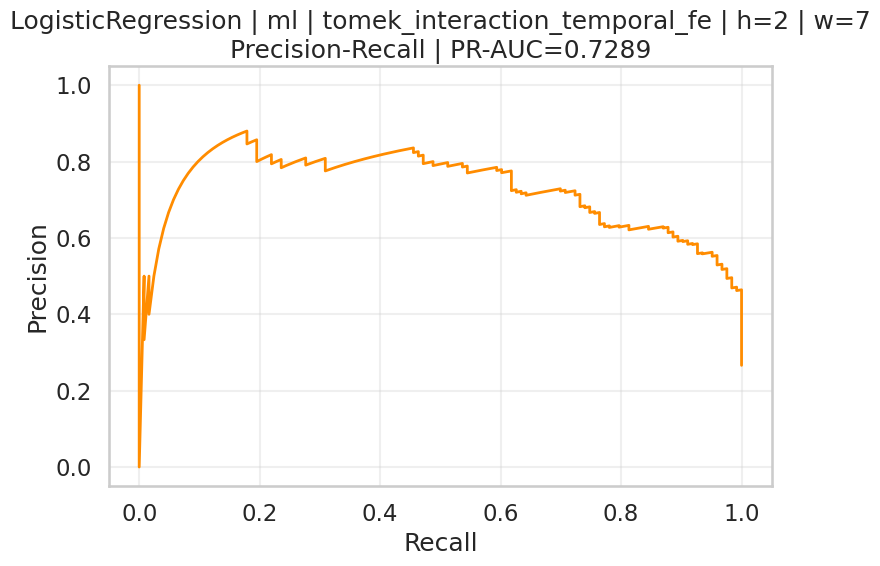

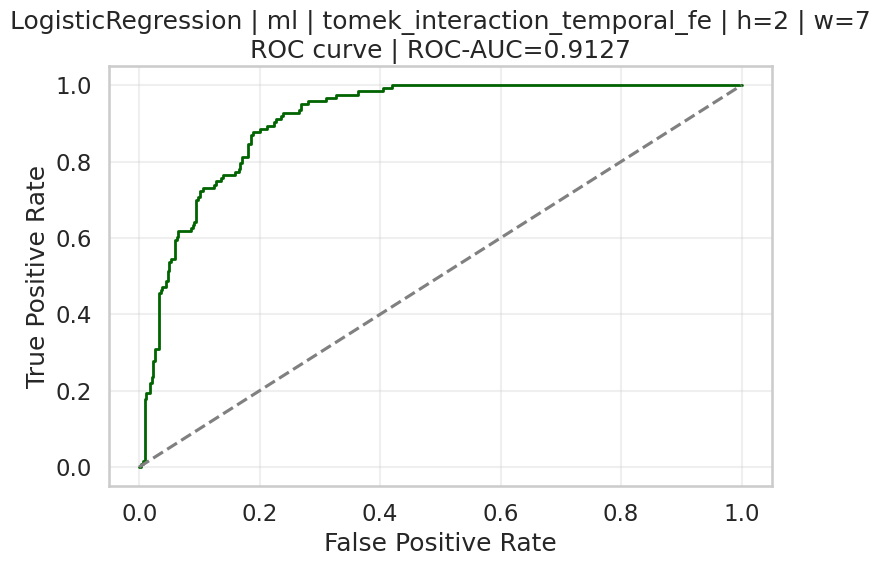

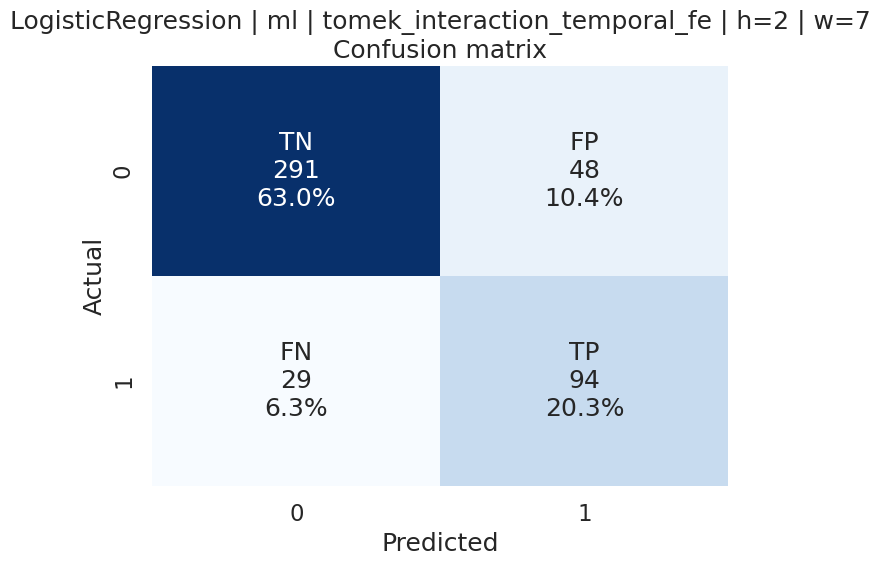

Saved best-so-far model plots and params: {'plot_precision_recall_path': '/kaggle/working/diploma_results/model_plots/20260421T194446Z__ml__LogisticRegression__tomek_interaction_temporal_fe__h2__w7__precision_recall.png', 'plot_roc_auc_path': '/kaggle/working/diploma_results/model_plots/20260421T194446Z__ml__LogisticRegression__tomek_interaction_temporal_fe__h2__w7__roc_auc.png', 'plot_confusion_matrix_path': '/kaggle/working/diploma_results/model_plots/20260421T194446Z__ml__LogisticRegression__tomek_interaction_temporal_fe__h2__w7__confusion_matrix.png', 'params_path': '/kaggle/working/diploma_results/model_artifacts/20260421T194446Z__ml__LogisticRegression__tomek_interaction_temporal_fe__h2__w7__params.json'}


In [37]:

TABULAR_MODEL_FLAGS = {
    "logreg": RUN_MODELS["logreg"],
    "svm": RUN_MODELS["svm"],
    "rf": RUN_MODELS["rf"],
    "xgb": RUN_MODELS["xgb"],
    "lgbm": RUN_MODELS["lgbm"],
    "catboost": RUN_MODELS["catboost"],
}

TABULAR_MODEL_NAMES = {
    "logreg": "LogisticRegression",
    "svm": "SVM",
    "rf": "RandomForest",
    "xgb": "XGBoost",
    "lgbm": "LightGBM",
    "catboost": "CatBoost",
}

for model_key, should_run in TABULAR_MODEL_FLAGS.items():
    if not should_run:
        continue
    for horizon in HORIZONS:
        for window_size in TABULAR_WINDOW_SIZES:
            for variant in APPLICABLE_VARIANTS["ml"]:
                try:
                    dataset = get_prepared_tabular_dataset(horizon, window_size, variant)
                    X_train, y_train = sanitize_xy(dataset["X_train"], dataset["y_train"])
                    X_val, y_val = sanitize_xy(dataset["X_val"], dataset["y_val"])
                    X_test, y_test = sanitize_xy(dataset["X_test"], dataset["y_test"])
                    meta_test = dataset["meta_test"].reset_index(drop=True)

                    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
                        raise ValueError("One of the tabular splits is empty after feature preparation.")

                    tune_trials = N_TRIALS_OPTUNA if model_key != "logreg" else max(8, N_TRIALS_OPTUNA // 2)
                    tune_start = time.perf_counter()
                    tuning_result = optuna_tune_tabular_model(model_key, X_train, y_train, X_val, y_val, n_trials=tune_trials)
                    best_params = tuning_result["best_params"]
                    model = build_model_by_name(model_key, best_params, y_train)
                    model = fit_estimator(model_key, model, X_train, y_train, X_val, y_val)
                    train_time = time.perf_counter() - tune_start

                    inference_start = time.perf_counter()
                    val_scores = get_score_vector(model, X_val)
                    test_scores = get_score_vector(model, X_test)
                    inference_time = time.perf_counter() - inference_start

                    evaluate_model(
                        model_name=TABULAR_MODEL_NAMES[model_key],
                        method_family="ml",
                        variant=variant,
                        horizon=horizon,
                        window_size=window_size,
                        y_val=y_val.values,
                        val_scores=val_scores,
                        y_test=y_test.values,
                        test_scores=test_scores,
                        meta_test=meta_test,
                        best_params=best_params,
                        tuned=True,
                        train_time=train_time,
                        inference_time=inference_time,
                        notes=dataset["notes"],
                    )
                except Exception as e:
                    log_error(TABULAR_MODEL_NAMES[model_key], "ml", variant, horizon, window_size, e)
                    print(f"{TABULAR_MODEL_NAMES[model_key]} failed for h={horizon}, w={window_size}, variant={variant}: {e}")



## Раздел 13.3. GRU

GRU обучается на year-aware последовательностях длины 7/9/12, построенных только внутри года. Масштабирование признаков выполняется по train-последовательностям и затем переносится на val/test.


[I 2026-04-21 18:23:19,191] A new study created in memory with name: no-name-a789d09d-aaae-4724-99ee-0d3b39ef7159


GRU: enabling torch.nn.DataParallel on GPUs [0, 1]


[I 2026-04-21 18:23:26,303] Trial 0 finished with value: 1.47810842985843 and parameters: {'hidden_size': 32, 'num_layers': 3, 'dropout': 0.35667539863597963, 'learning_rate': 0.004655506399270412, 'batch_size': 128}. Best is trial 0 with value: 1.47810842985843.


GRU: enabling torch.nn.DataParallel on GPUs [0, 1]


[I 2026-04-21 18:23:33,105] Trial 1 finished with value: 1.2438432432432431 and parameters: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.27169232147912786, 'learning_rate': 0.0018891868312777926, 'batch_size': 32}. Best is trial 0 with value: 1.47810842985843.


...

GRU: enabling torch.nn.DataParallel on GPUs [0, 1]


[I 2026-04-21 18:24:26,703] Trial 8 finished with value: 1.019018018018018 and parameters: {'hidden_size': 32, 'num_layers': 3, 'dropout': 0.4405247781030335, 'learning_rate': 0.00030304658440947146, 'batch_size': 128}. Best is trial 0 with value: 1.47810842985843.


GRU: enabling torch.nn.DataParallel on GPUs [0, 1]


[I 2026-04-21 18:24:32,057] Trial 9 finished with value: 1.27087027027027 and parameters: {'hidden_size': 64, 'num_layers': 3, 'dropout': 0.4935436691446134, 'learning_rate': 0.0008177153557711889, 'batch_size': 128}. Best is trial 0 with value: 1.47810842985843.


GRU: enabling torch.nn.DataParallel on GPUs [0, 1]


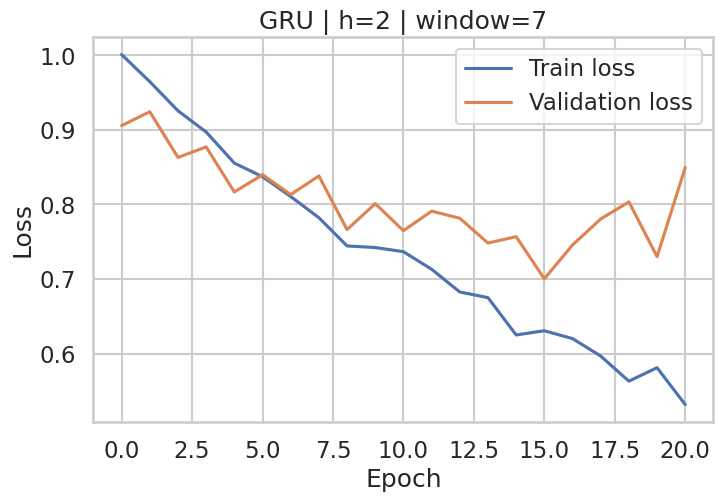

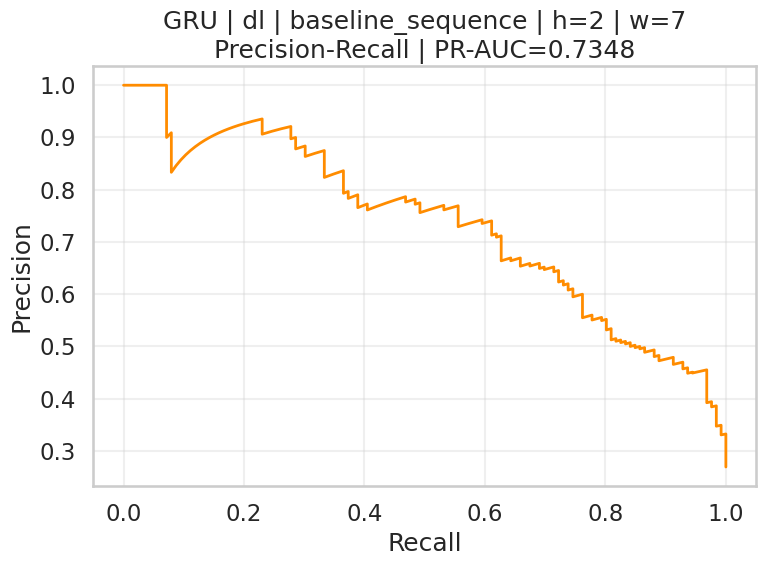

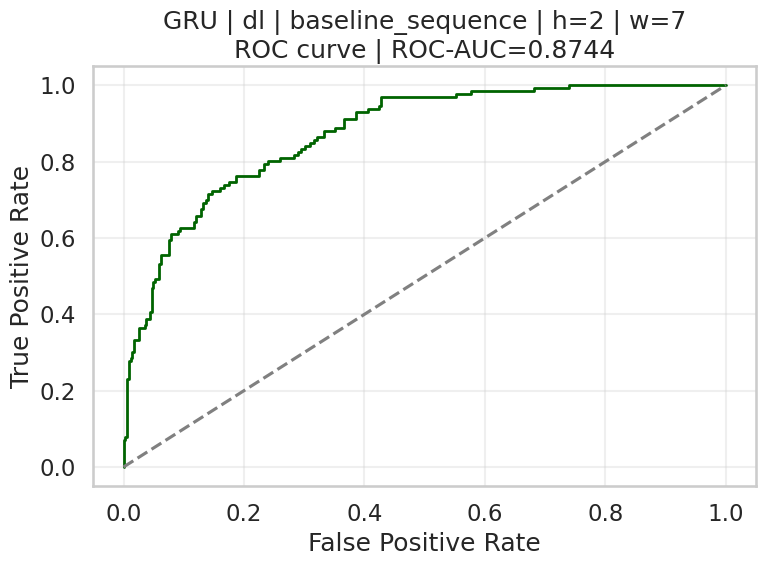

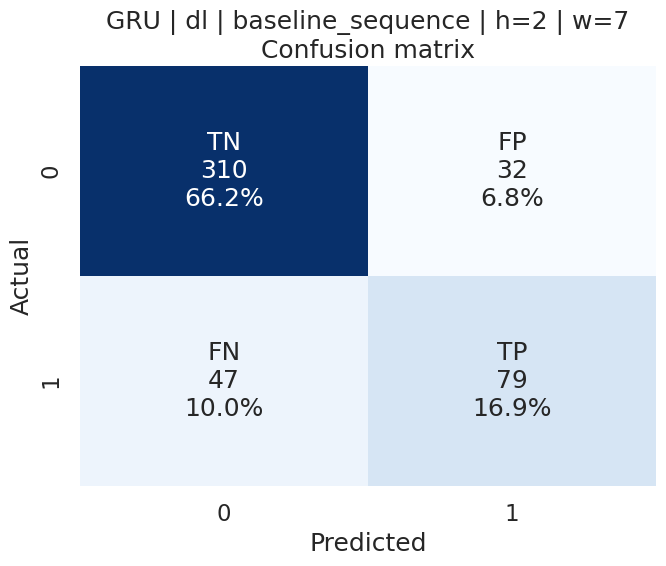

[I 2026-04-21 18:24:37,880] A new study created in memory with name: no-name-6c90ed4d-14e1-4a8b-acec-0e2a6df11e6b


Saved best-so-far model plots and params: {'plot_precision_recall_path': '/kaggle/working/diploma_results/model_plots/20260421T182436Z__dl__GRU__baseline_sequence__h2__w7__precision_recall.png', 'plot_roc_auc_path': '/kaggle/working/diploma_results/model_plots/20260421T182436Z__dl__GRU__baseline_sequence__h2__w7__roc_auc.png', 'plot_confusion_matrix_path': '/kaggle/working/diploma_results/model_plots/20260421T182436Z__dl__GRU__baseline_sequence__h2__w7__confusion_matrix.png', 'params_path': '/kaggle/working/diploma_results/model_artifacts/20260421T182436Z__dl__GRU__baseline_sequence__h2__w7__params.json'}
GRU: enabling torch.nn.DataParallel on GPUs [0, 1]


[I 2026-04-21 18:24:48,036] Trial 0 finished with value: 1.4439987905176586 and parameters: {'hidden_size': 80, 'num_layers': 2, 'dropout': 0.2198217303967292, 'learning_rate': 0.001406259964166527, 'batch_size': 16}. Best is trial 0 with value: 1.4439987905176586.


GRU: enabling torch.nn.DataParallel on GPUs [0, 1]


[I 2026-04-21 18:24:54,682] Trial 1 finished with value: 1.2741890723270441 and parameters: {'hidden_size': 112, 'num_layers': 1, 'dropout': 0.4642289095402666, 'learning_rate': 0.0011178517870103811, 'batch_size': 32}. Best is trial 0 with value: 1.4439987905176586.


...

GRU: enabling torch.nn.DataParallel on GPUs [0, 1]


[I 2026-04-21 18:26:04,127] Trial 8 finished with value: 1.0195345911949685 and parameters: {'hidden_size': 32, 'num_layers': 3, 'dropout': 0.21771043194370765, 'learning_rate': 0.001418066463603619, 'batch_size': 128}. Best is trial 5 with value: 1.613809399021663.


GRU: enabling torch.nn.DataParallel on GPUs [0, 1]


[I 2026-04-21 18:26:07,823] Trial 9 finished with value: 1.0289018867924529 and parameters: {'hidden_size': 128, 'num_layers': 1, 'dropout': 0.06772236524806358, 'learning_rate': 0.00017490337571688435, 'batch_size': 128}. Best is trial 5 with value: 1.613809399021663.


GRU: enabling torch.nn.DataParallel on GPUs [0, 1]


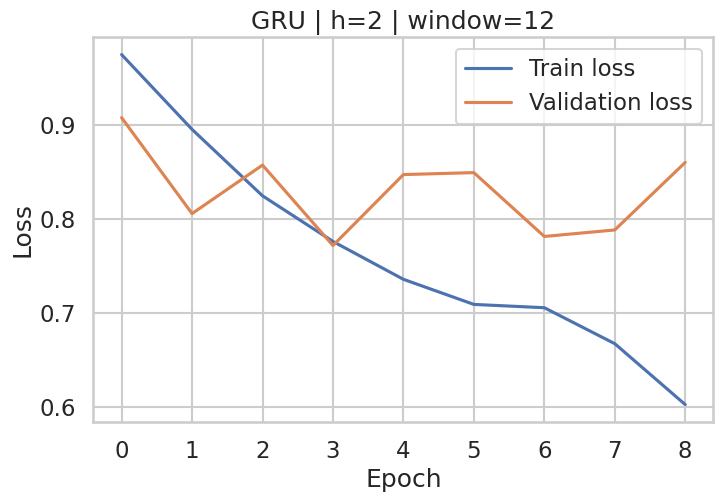

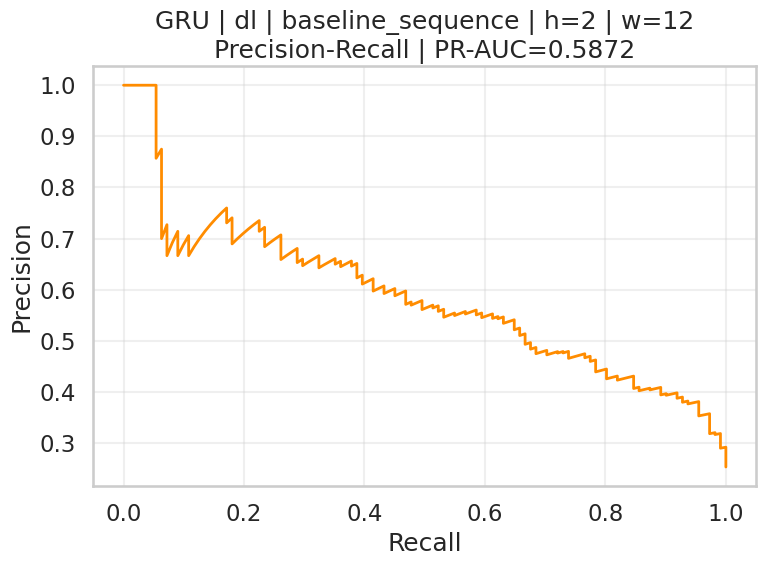

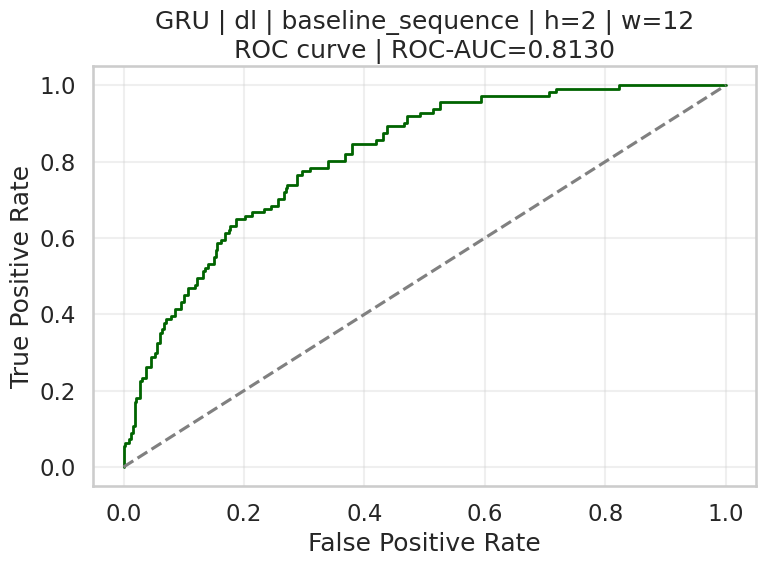

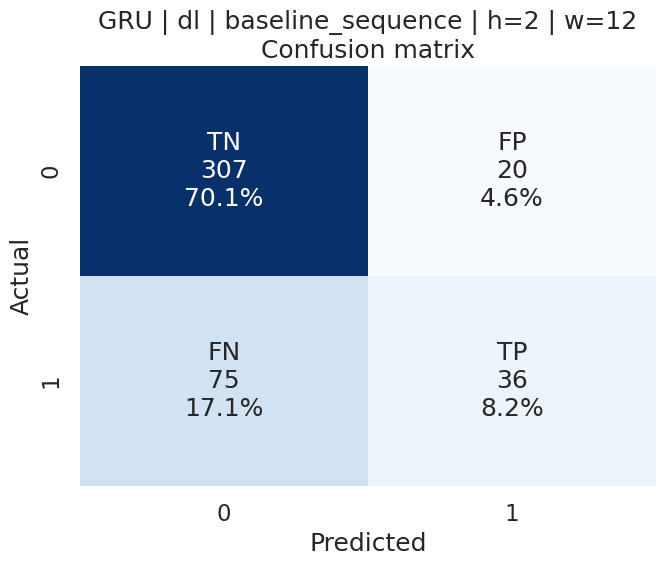

Saved best-so-far model plots and params: {'plot_precision_recall_path': '/kaggle/working/diploma_results/model_plots/20260421T182611Z__dl__GRU__baseline_sequence__h2__w12__precision_recall.png', 'plot_roc_auc_path': '/kaggle/working/diploma_results/model_plots/20260421T182611Z__dl__GRU__baseline_sequence__h2__w12__roc_auc.png', 'plot_confusion_matrix_path': '/kaggle/working/diploma_results/model_plots/20260421T182611Z__dl__GRU__baseline_sequence__h2__w12__confusion_matrix.png', 'params_path': '/kaggle/working/diploma_results/model_artifacts/20260421T182611Z__dl__GRU__baseline_sequence__h2__w12__params.json'}


In [12]:

class GRUClassifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_layers: int, dropout: float):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        output, _ = self.gru(x)
        last_hidden = output[:, -1, :]
        logits = self.fc(self.dropout(last_hidden)).squeeze(-1)
        return logits


def scale_sequence_arrays(X_train: np.ndarray, X_val: np.ndarray, X_test: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, StandardScaler]:
    scaler = StandardScaler()
    n_features = X_train.shape[-1]
    scaler.fit(X_train.reshape(-1, n_features))
    X_train_scaled = scaler.transform(X_train.reshape(-1, n_features)).reshape(X_train.shape)
    X_val_scaled = scaler.transform(X_val.reshape(-1, n_features)).reshape(X_val.shape)
    X_test_scaled = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)
    return X_train_scaled, X_val_scaled, X_test_scaled, scaler


def create_sequence_loader(X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    dataset = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=DL_NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )


def maybe_wrap_data_parallel(model: nn.Module) -> nn.Module:
    if USE_MULTI_GPU:
        print(f"GRU: enabling torch.nn.DataParallel on GPUs {GPU_DEVICE_IDS}")
        return nn.DataParallel(model, device_ids=GPU_DEVICE_IDS)
    return model


def move_batch_to_device(xb: torch.Tensor, yb: Optional[torch.Tensor] = None):
    xb = xb.to(DEVICE, non_blocking=PIN_MEMORY)
    if yb is None:
        return xb
    return xb, yb.to(DEVICE, non_blocking=PIN_MEMORY)


def train_gru_model(X_train, y_train, X_val, y_val, params: Dict[str, Any]):
    model = GRUClassifier(
        input_size=X_train.shape[-1],
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"],
        dropout=params["dropout"],
    ).to(DEVICE)
    model = maybe_wrap_data_parallel(model)

    batch_size = params["batch_size"]
    train_loader = create_sequence_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
    val_loader = create_sequence_loader(X_val, y_val, batch_size=batch_size, shuffle=False)

    pos_count = max(1.0, float(y_train.sum()))
    neg_count = max(1.0, float(len(y_train) - y_train.sum()))
    pos_weight = torch.tensor([neg_count / pos_count], dtype=torch.float32, device=DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=params["learning_rate"])

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = np.inf
    best_state = deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(MAX_EPOCHS_DL):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = move_batch_to_device(xb, yb)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = move_batch_to_device(xb, yb)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_losses.append(loss.item())

        avg_train_loss = float(np.mean(train_losses)) if train_losses else np.nan
        avg_val_loss = float(np.mean(val_losses)) if val_losses else np.nan
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)

        if avg_val_loss < best_val_loss - 1e-4:
            best_val_loss = avg_val_loss
            best_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE_DL:
                break

    model.load_state_dict(best_state)
    return model, history, best_val_loss


def predict_gru_scores(model: nn.Module, X: np.ndarray, batch_size: int = 128) -> np.ndarray:
    loader = create_sequence_loader(X, np.zeros(len(X)), batch_size=batch_size, shuffle=False)
    model.eval()
    scores = []
    with torch.no_grad():
        for xb, _ in loader:
            xb = move_batch_to_device(xb)
            logits = model(xb)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            scores.extend(probs.tolist())
    return np.asarray(scores)


def tune_gru(X_train, y_train, X_val, y_val) -> Dict[str, Any]:
    def objective(trial: optuna.Trial) -> float:
        params = {
            "hidden_size": trial.suggest_int("hidden_size", 16, 128, step=16),
            "num_layers": trial.suggest_int("num_layers", 1, 3),
            "dropout": trial.suggest_float("dropout", 0.0, 0.5),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64, 128]),
        }
        model, _, _ = train_gru_model(X_train, y_train, X_val, y_val, params)
        val_scores = predict_gru_scores(model, X_val, batch_size=params["batch_size"])
        threshold_info = search_threshold(y_val, val_scores)
        score = threshold_objective_value(threshold_info["recall"], threshold_info["precision"])
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()
        return score

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=N_TRIALS_OPTUNA, show_progress_bar=False)
    return study.best_params


def plot_gru_history(history: Dict[str, List[float]], title: str) -> None:
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train loss")
    plt.plot(history["val_loss"], label="Validation loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


if RUN_MODELS["gru"]:
    for horizon in HORIZONS:
        target_col = f"target_h{horizon}"
        sequence_splits = prepare_sequence_splits(horizon)
        for window_size in WINDOW_SIZES:
            try:
                X_train, y_train, _ = build_sequences_year_aware(sequence_splits["train"], FEATURE_COLS, target_col, window_size)
                X_val, y_val, _ = build_sequences_year_aware(sequence_splits["val"], FEATURE_COLS, target_col, window_size)
                X_test, y_test, meta_test = build_sequences_year_aware(sequence_splits["test"], FEATURE_COLS, target_col, window_size)
                if min(len(X_train), len(X_val), len(X_test)) == 0:
                    raise ValueError("One of the GRU sequence splits is empty.")

                X_train, X_val, X_test, _ = scale_sequence_arrays(X_train, X_val, X_test)
                time_start = time.perf_counter()
                best_params = tune_gru(X_train, y_train, X_val, y_val)
                gru_model, gru_history, _ = train_gru_model(X_train, y_train, X_val, y_val, best_params)
                train_time = time.perf_counter() - time_start
                inference_start = time.perf_counter()
                val_scores = predict_gru_scores(gru_model, X_val, batch_size=best_params["batch_size"])
                test_scores = predict_gru_scores(gru_model, X_test, batch_size=best_params["batch_size"])
                inference_time = time.perf_counter() - inference_start
                plot_gru_history(gru_history, title=f"GRU | h={horizon} | window={window_size}")
                evaluate_model(
                    model_name="GRU",
                    method_family="dl",
                    variant="baseline_sequence",
                    horizon=horizon,
                    window_size=window_size,
                    y_val=y_val,
                    val_scores=val_scores,
                    y_test=y_test,
                    test_scores=test_scores,
                    meta_test=meta_test,
                    best_params=best_params,
                    tuned=True,
                    train_time=train_time,
                    inference_time=inference_time,
                    notes=f"PyTorch GRU with year-aware sequences; multi_gpu={USE_MULTI_GPU}; gpu_count={GPU_COUNT}; validation-based threshold selection.",
                    show_plots=True,
                )
            except Exception as e:
                log_error("GRU", "dl", "baseline_sequence", horizon, window_size, e)
                print(f"GRU failed for h={horizon}, w={window_size}: {e}")



## Раздел 13.3. TFT

Для TFT используется `TimeSeriesDataSet` и `TemporalFusionTransformer` из PyTorch Forecasting. Цель трактуется как категориальная бинарная переменная с функцией потерь `CrossEntropy`. Если конкретная связка версий пакетов окажется нестабильной, блок сохраняет ошибку и продолжает выполнение ноутбука.


[I 2026-04-21 18:30:51,549] A new study created in memory with name: no-name-e8427c4c-ed0a-4807-a725-0cfcd155214a
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Output()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
2026-04-21 18:31:23.171657: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been regist

Output()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
[I 2026-04-21 18:32:21,611] Trial 1 finished with value: 0.5456727272727272 and parameters: {'hidden_size': 32, 'attention_head_size': 2, 'dropout': 0.3272572499

...

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
[I 2026-04-21 18:40:10,850] Trial 8 finished with value: 1.1006111111111112 and parameters: {'hidden_size': 24, 'attention_head_size': 2, 'dropout': 0.0915135016

Output()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
[I 2026-04-21 18:40:51,391] Trial 9 finished with value: 1.118866028708134 and parameters: {'hidden_size': 64, 'attention_head_size': 1, 'dropout': 0.08094406581

Output()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note tha

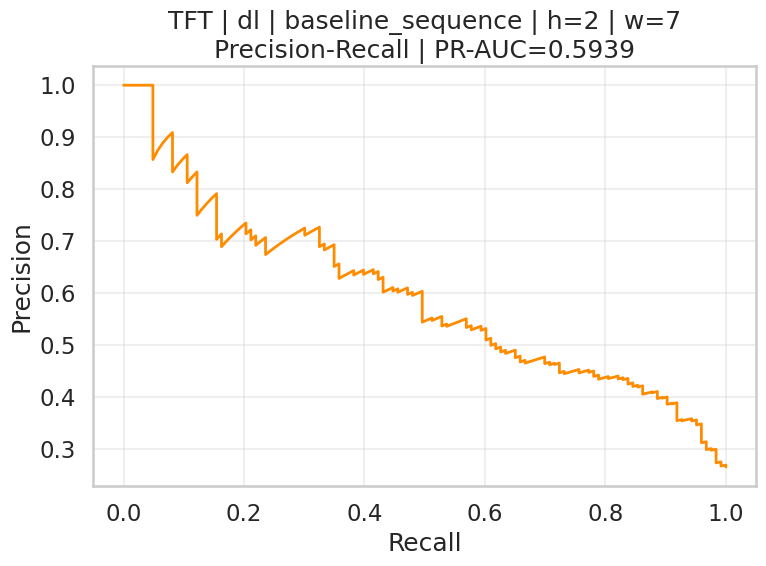

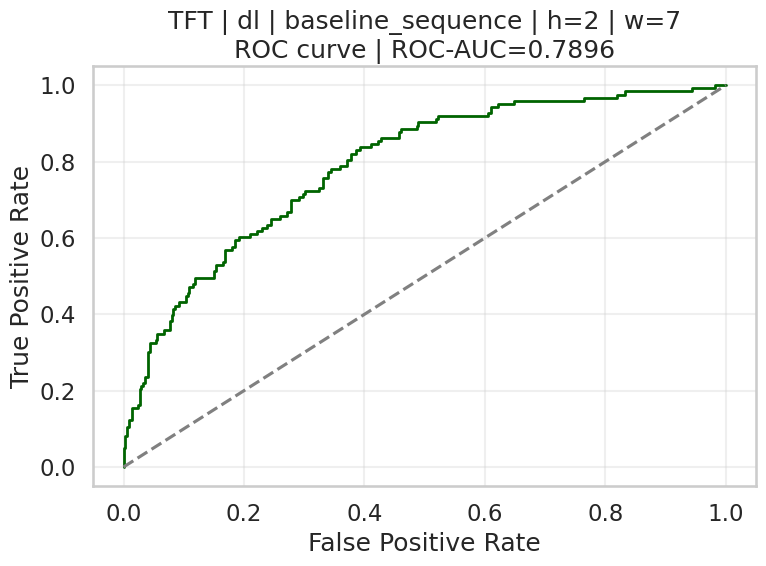

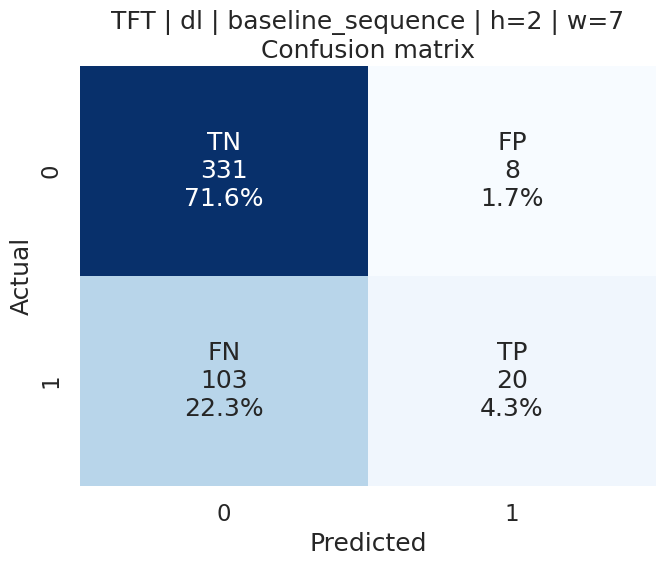

Saved best-so-far model plots and params: {'plot_precision_recall_path': '/kaggle/working/diploma_results/model_plots/20260421T184133Z__dl__TFT__baseline_sequence__h2__w7__precision_recall.png', 'plot_roc_auc_path': '/kaggle/working/diploma_results/model_plots/20260421T184133Z__dl__TFT__baseline_sequence__h2__w7__roc_auc.png', 'plot_confusion_matrix_path': '/kaggle/working/diploma_results/model_plots/20260421T184133Z__dl__TFT__baseline_sequence__h2__w7__confusion_matrix.png', 'params_path': '/kaggle/working/diploma_results/model_artifacts/20260421T184133Z__dl__TFT__baseline_sequence__h2__w7__params.json'}


[I 2026-04-21 18:41:34,958] A new study created in memory with name: no-name-37528ed0-6e5e-4b8a-9fab-f8d84a88625d
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Output()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
[I 2026-04-21 18:42:06,024] Trial 0 finished with value: 1.0106153846153845 and parameters: {'hidden_size': 8, 'attention_head_size': 3, 'dropout': 0.06341417732

Output()

...

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
[I 2026-04-21 18:50:52,279] Trial 8 finished with value: 1.2217927350427351 and parameters: {'hidden_size': 56, 'attention_head_size': 3, 'dropout': 0.2662446979

Output()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
[I 2026-04-21 18:51:35,431] Trial 9 finished with value: 1.0967788461538464 and parameters: {'hidden_size': 40, 'attention_head_size': 3, 'dropout': 0.3811973616

Output()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note tha

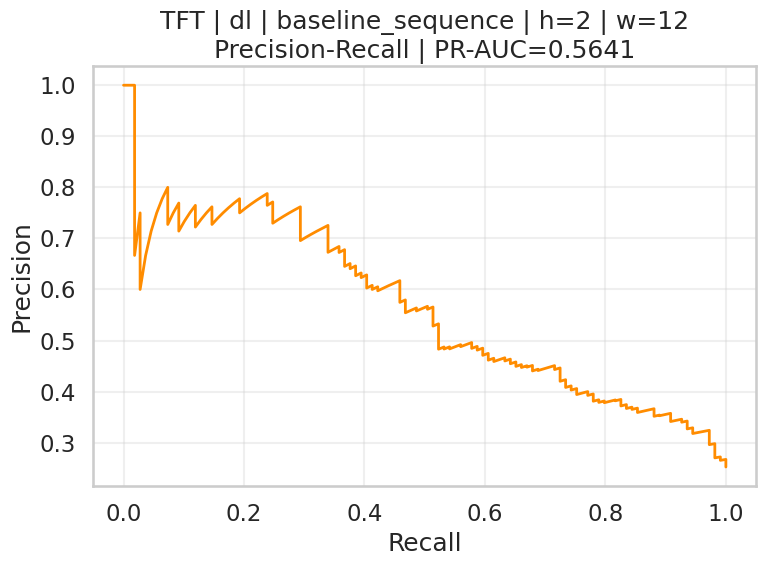

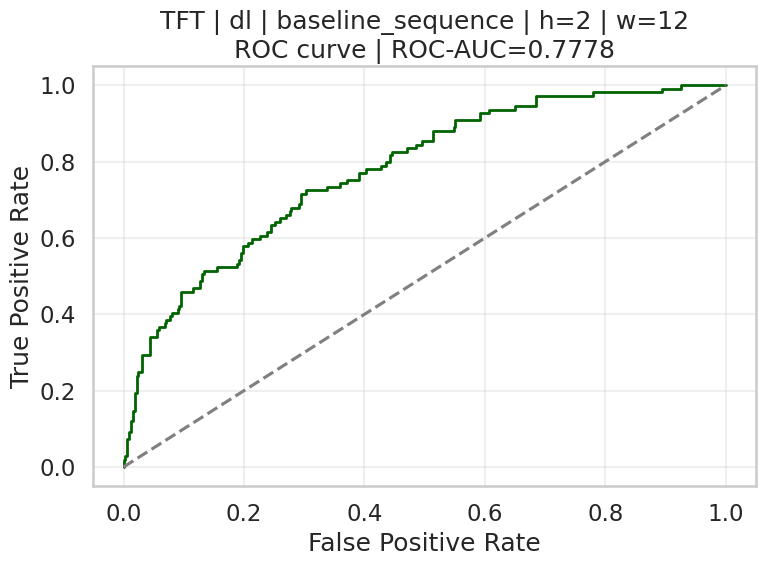

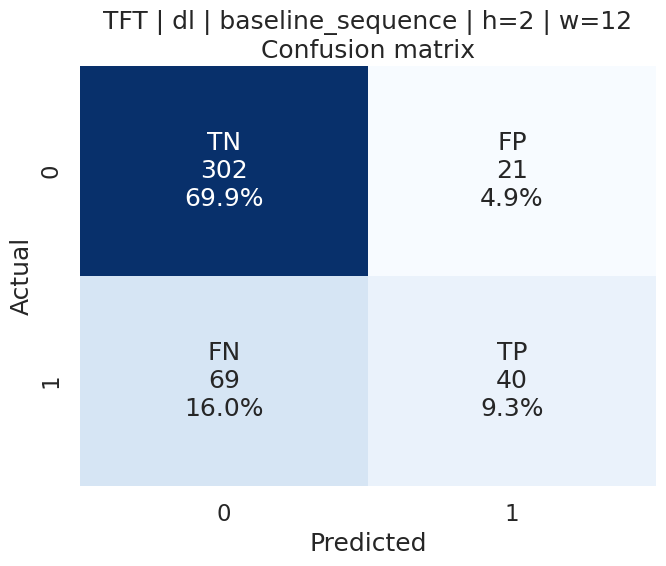

Saved best-so-far model plots and params: {'plot_precision_recall_path': '/kaggle/working/diploma_results/model_plots/20260421T185203Z__dl__TFT__baseline_sequence__h2__w12__precision_recall.png', 'plot_roc_auc_path': '/kaggle/working/diploma_results/model_plots/20260421T185203Z__dl__TFT__baseline_sequence__h2__w12__roc_auc.png', 'plot_confusion_matrix_path': '/kaggle/working/diploma_results/model_plots/20260421T185203Z__dl__TFT__baseline_sequence__h2__w12__confusion_matrix.png', 'params_path': '/kaggle/working/diploma_results/model_artifacts/20260421T185203Z__dl__TFT__baseline_sequence__h2__w12__params.json'}


In [15]:

def prepare_tft_frames(horizon: int) -> Dict[str, pd.DataFrame]:
    target_col = f"target_h{horizon}"
    train_df, fill_values = fill_weather_missing(datasets_by_horizon[horizon]["train"])
    val_df, _ = fill_weather_missing(datasets_by_horizon[horizon]["val"], fill_values)
    test_df, _ = fill_weather_missing(datasets_by_horizon[horizon]["test"], fill_values)

    prepared = {}
    for split_name, frame in {"train": train_df, "val": val_df, "test": test_df}.items():
        frame = frame.copy().sort_values(["year", "day"]).reset_index(drop=True)
        frame["series_id"] = frame["year"].astype(str)
        frame["time_idx"] = frame.groupby("year").cumcount()
        frame[target_col] = frame[target_col].round().astype(int).astype(str)
        prepared[split_name] = frame
    return prepared


def build_tft_datasets(horizon: int, window_size: int):
    if TimeSeriesDataSet is None or TemporalFusionTransformer is None or NaNLabelEncoder is None or CrossEntropy is None:
        raise ImportError("PyTorch Forecasting is not available in the current runtime.")

    target_col = f"target_h{horizon}"
    frames = prepare_tft_frames(horizon)

    training = TimeSeriesDataSet(
        frames["train"],
        time_idx="time_idx",
        target=target_col,
        group_ids=["series_id"],
        max_encoder_length=window_size,
        min_encoder_length=window_size,
        max_prediction_length=1,
        min_prediction_length=1,
        time_varying_known_reals=["time_idx"] + FEATURE_COLS,
        time_varying_unknown_reals=[],
        target_normalizer=NaNLabelEncoder(),
        allow_missing_timesteps=True,
        add_relative_time_idx=False,
        add_target_scales=False,
        randomize_length=False,
    )
    validation = TimeSeriesDataSet.from_dataset(training, frames["val"], stop_randomization=True, predict=False)
    testing = TimeSeriesDataSet.from_dataset(training, frames["test"], stop_randomization=True, predict=False)
    return frames, training, validation, testing


def get_tft_true_labels(frame: pd.DataFrame, target_col: str, window_size: int) -> Tuple[np.ndarray, pd.DataFrame]:
    y_true = []
    meta_rows = []
    for year, group in frame.groupby("year"):
        group = group.sort_values("day").reset_index(drop=True)
        if len(group) <= window_size:
            continue
        for idx in range(window_size, len(group)):
            y_true.append(int(group[target_col].iloc[idx]))
            meta_rows.append({"year": int(group["year"].iloc[idx]), "day": int(group["day"].iloc[idx])})
    return np.array(y_true), pd.DataFrame(meta_rows)


def extract_tft_positive_scores(prediction_output) -> np.ndarray:
    pred = prediction_output
    if hasattr(prediction_output, "output"):
        pred = prediction_output.output
    if hasattr(pred, "prediction"):
        pred = pred.prediction
    elif isinstance(pred, dict) and "prediction" in pred:
        pred = pred["prediction"]
    elif isinstance(pred, (tuple, list)) and len(pred) > 0:
        pred = pred[0]

    pred_tensor = torch.as_tensor(pred)
    if pred_tensor.ndim == 3:
        pred_tensor = pred_tensor[:, -1, :]
    if pred_tensor.ndim == 2 and pred_tensor.shape[1] == 2:
        probs = torch.softmax(pred_tensor, dim=1)[:, 1]
    else:
        probs = torch.sigmoid(pred_tensor.reshape(-1))
    return probs.detach().cpu().numpy()


def create_tft_trainer(callbacks: Optional[List[Any]] = None) -> pl.Trainer:
    trainer_kwargs = get_tft_trainer_kwargs()
    return pl.Trainer(
        max_epochs=MAX_EPOCHS_DL,
        deterministic="warn",   # было True
        logger=False,
        enable_checkpointing=False,
        enable_model_summary=False,
        callbacks=callbacks or [],
        gradient_clip_val=0.1,
        num_sanity_val_steps=0,
        **trainer_kwargs,
    )

def tune_tft(training, validation_loader, frames_val, target_col: str, window_size: int) -> Dict[str, Any]:
    y_val_true, _ = get_tft_true_labels(frames_val, target_col, window_size)

    def objective(trial: optuna.Trial) -> float:
        params = {
            "hidden_size": trial.suggest_int("hidden_size", 8, 64, step=8),
            "attention_head_size": trial.suggest_int("attention_head_size", 1, 4),
            "dropout": trial.suggest_float("dropout", 0.05, 0.5),
            "hidden_continuous_size": trial.suggest_int("hidden_continuous_size", 4, 32, step=4),
            "lstm_layers": trial.suggest_int("lstm_layers", 1, 2),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 5e-2, log=True),
        }
        model = TemporalFusionTransformer.from_dataset(
            training,
            learning_rate=params["learning_rate"],
            hidden_size=params["hidden_size"],
            attention_head_size=params["attention_head_size"],
            dropout=params["dropout"],
            hidden_continuous_size=params["hidden_continuous_size"],
            lstm_layers=params["lstm_layers"],
            loss=CrossEntropy(),
            output_size=2,
            reduce_on_plateau_patience=2,
        )
        early_stop = EarlyStopping(monitor="val_loss", patience=PATIENCE_DL, mode="min")
        trainer = create_tft_trainer(callbacks=[early_stop])
        trainer.fit(model, train_dataloaders=training.to_dataloader(train=True, batch_size=64, num_workers=0), val_dataloaders=validation_loader)
        raw_pred = model.predict(validation_loader, mode="raw")
        val_scores = extract_tft_positive_scores(raw_pred)
        usable_len = min(len(y_val_true), len(val_scores))
        threshold_info = search_threshold(y_val_true[:usable_len], val_scores[:usable_len])
        return threshold_objective_value(threshold_info["recall"], threshold_info["precision"])

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=min(N_TRIALS_OPTUNA, 10), show_progress_bar=False)
    return study.best_params


if RUN_MODELS["tft"]:
    for horizon in HORIZONS:
        target_col = f"target_h{horizon}"
        for window_size in WINDOW_SIZES:
            try:
                frames, training_ds, validation_ds, test_ds = build_tft_datasets(horizon, window_size)
                effective_train_batch_size = 64
                effective_eval_batch_size = 128
                train_loader = training_ds.to_dataloader(train=True, batch_size=effective_train_batch_size, num_workers=DL_NUM_WORKERS)
                val_loader = validation_ds.to_dataloader(train=False, batch_size=effective_eval_batch_size, num_workers=DL_NUM_WORKERS)
                test_loader = test_ds.to_dataloader(train=False, batch_size=effective_eval_batch_size, num_workers=DL_NUM_WORKERS)

                y_val_true, _ = get_tft_true_labels(frames["val"], target_col, window_size)
                y_test_true, meta_test = get_tft_true_labels(frames["test"], target_col, window_size)

                time_start = time.perf_counter()
                best_params = tune_tft(training_ds, val_loader, frames["val"], target_col, window_size)
                tft_model = TemporalFusionTransformer.from_dataset(
                    training_ds,
                    learning_rate=best_params["learning_rate"],
                    hidden_size=best_params["hidden_size"],
                    attention_head_size=best_params["attention_head_size"],
                    dropout=best_params["dropout"],
                    hidden_continuous_size=best_params["hidden_continuous_size"],
                    lstm_layers=best_params["lstm_layers"],
                    loss=CrossEntropy(),
                    output_size=2,
                    reduce_on_plateau_patience=2,
                )
                early_stop = EarlyStopping(monitor="val_loss", patience=PATIENCE_DL, mode="min")
                trainer = create_tft_trainer(callbacks=[early_stop])
                trainer.fit(tft_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
                train_time = time.perf_counter() - time_start

                inference_start = time.perf_counter()
                val_raw = tft_model.predict(val_loader, mode="raw")
                test_raw = tft_model.predict(test_loader, mode="raw")
                val_scores = extract_tft_positive_scores(val_raw)
                test_scores = extract_tft_positive_scores(test_raw)
                inference_time = time.perf_counter() - inference_start

                usable_val = min(len(y_val_true), len(val_scores))
                usable_test = min(len(y_test_true), len(test_scores), len(meta_test))
                if usable_val == 0 or usable_test == 0:
                    raise ValueError("TFT produced zero usable predictions.")
                evaluate_model(
                    model_name="TFT",
                    method_family="dl",
                    variant="baseline_sequence",
                    horizon=horizon,
                    window_size=window_size,
                    y_val=y_val_true[:usable_val],
                    val_scores=val_scores[:usable_val],
                    y_test=y_test_true[:usable_test],
                    test_scores=test_scores[:usable_test],
                    meta_test=meta_test.iloc[:usable_test].reset_index(drop=True),
                    best_params=best_params,
                    tuned=True,
                    train_time=train_time,
                    inference_time=inference_time,
                    notes=f"TemporalFusionTransformer with categorical target and CrossEntropy loss; lightning_trainer={get_tft_trainer_kwargs()}. If this block fails in a specific notebook runtime, inspect error_log_df.",
                    show_plots=True,
                )
            except Exception as e:
                log_error("TFT", "dl", "baseline_sequence", horizon, window_size, e)
                print(f"TFT failed for h={horizon}, w={window_size}: {e}")



## Раздел 13.4. Rule-based domain baseline: BLITECAST и SIMCAST

Ниже реализованы **приближения**, а не буквальные копии оригинальных DSS:
- BLITECAST: используется суточный риск `0..4`, потому что в extension-источниках BLITECAST описывается как weather-based daily risk value, а порог 18 DSV широко используется как практический trigger.
- SIMCAST: из публикаций и extension-материалов следует, что модель использует weather data, host resistance, fungicide effects и blight units; при этом осадки часто являются сильнейшим драйвером сигнала. Поскольку у нас нет признаков фунгицида и устойчивости сорта, реализуется weather-only approximation с rolling BU-score.


In [23]:

def compute_blitecast_daily_score(df: pd.DataFrame) -> pd.Series:
    score = pd.Series(0.0, index=df.index)
    rain_signal = ((df["is_rain"] > 0) | (df["precipitation"] >= 0.1)).astype(int)
    score += np.where((df["t_avg"] >= 10) & (df["t_avg"] <= 24), 2.0, 0.0)
    score += np.where(((df["t_avg"] >= 7) & (df["t_avg"] < 10)) | ((df["t_avg"] > 24) & (df["t_avg"] <= 27)), 1.0, 0.0)
    score += rain_signal * 1.0
    score += np.where(df["cloudiness"] >= 6, 1.0, 0.0)
    return score.clip(0, 4)


def compute_simcast_daily_score(df: pd.DataFrame) -> pd.Series:
    score = pd.Series(0.0, index=df.index)
    rain_signal = ((df["is_rain"] > 0) | (df["precipitation"] >= 0.1)).astype(int)
    score += rain_signal * 2.0
    score += np.where((df["t_avg"] >= 10) & (df["t_avg"] <= 23), 2.0, 0.0)
    score += np.where(df["t_min"] >= 10, 1.0, 0.0)
    score += np.where(df["cloudiness"] >= 6, 1.0, 0.0)
    return score.clip(0, 6)


def build_rule_based_scores(horizon: int, window_size: int, model_name: str) -> Dict[str, Any]:
    target_col = f"target_h{horizon}"
    train_df, fill_values = fill_weather_missing(datasets_by_horizon[horizon]["train"])
    val_df, _ = fill_weather_missing(datasets_by_horizon[horizon]["val"], fill_values)
    test_df, _ = fill_weather_missing(datasets_by_horizon[horizon]["test"], fill_values)

    prepared_frames = []
    for frame in [train_df, val_df, test_df]:
        frame = frame.copy().sort_values(["year", "day"]).reset_index(drop=True)
        if model_name == "BLITECAST":
            frame["rule_score_daily"] = compute_blitecast_daily_score(frame).to_numpy()
        else:
            frame["rule_score_daily"] = compute_simcast_daily_score(frame).to_numpy()
        frame["rule_score"] = (
            frame.groupby("year", group_keys=False)["rule_score_daily"]
            .rolling(window_size, min_periods=window_size)
            .sum()
            .reset_index(level=0, drop=True)
            .to_numpy()
        )
        prepared_frames.append(frame)
    train_df, val_df, test_df = prepared_frames

    def finalize_rule(frame: pd.DataFrame):
        subset = frame[["year", "day", target_col, "rule_score"]].dropna().reset_index(drop=True)
        y_true = subset[target_col].astype(int).values
        scores = subset["rule_score"].astype(float).values
        meta = subset[["year", "day"]].copy()
        return y_true, scores, meta

    y_train, train_scores, meta_train = finalize_rule(train_df)
    y_val, val_scores, meta_val = finalize_rule(val_df)
    y_test, test_scores, meta_test = finalize_rule(test_df)
    return {
        "y_train": y_train,
        "train_scores": train_scores,
        "meta_train": meta_train,
        "y_val": y_val,
        "val_scores": val_scores,
        "meta_val": meta_val,
        "y_test": y_test,
        "test_scores": test_scores,
        "meta_test": meta_test,
    }


for rule_model, flag in {"BLITECAST": RUN_MODELS["blitecast"], "SIMCAST": RUN_MODELS["simcast"]}.items():
    if not flag:
        continue
    for horizon in HORIZONS:
        for window_size in WINDOW_SIZES:
            try:
                start_time = time.perf_counter()
                payload = build_rule_based_scores(horizon, window_size, rule_model)
                total_time = time.perf_counter() - start_time
                if len(payload["y_val"]) == 0 or len(payload["y_test"]) == 0:
                    raise ValueError("Rule-based model produced empty validation or test arrays.")
                notes = {
                    "BLITECAST": "Approximate DSV model on daily aggregates; canonical agronomic threshold is often discussed around 18 accumulated DSV.",
                    "SIMCAST": "Approximate BU model on daily aggregates; host resistance and fungicide residue are unavailable and therefore omitted explicitly.",
                }[rule_model]
                evaluate_model(
                    model_name=rule_model,
                    method_family="rule-based",
                    variant="domain_rule",
                    horizon=horizon,
                    window_size=window_size,
                    y_val=payload["y_val"],
                    val_scores=payload["val_scores"],
                    y_test=payload["y_test"],
                    test_scores=payload["test_scores"],
                    meta_test=payload["meta_test"],
                    best_params={"rolling_window": window_size},
                    tuned=False,
                    train_time=total_time,
                    inference_time=0.0,
                    notes=notes,
                )
            except Exception as e:
                log_error(rule_model, "rule-based", "domain_rule", horizon, window_size, e)
                print(f"{rule_model} failed for h={horizon}, w={window_size}: {e}")



## Раздел 13.5. Ансамбли: Stacking и Voting

- Для stacking используется `TimeSeriesSplit`, а не случайный `KFold`, чтобы мета-модель не видела будущие наблюдения при построении OOF-предсказаний.
- `VotingClassifier` строится в soft-voting режиме, поскольку все базовые модели в ансамбле выдают вероятности.


In [24]:

def parse_best_params(raw_value: Any) -> Dict[str, Any]:
    if raw_value is None or (isinstance(raw_value, float) and np.isnan(raw_value)):
        return {}
    if isinstance(raw_value, dict):
        return raw_value
    try:
        return json.loads(raw_value)
    except Exception:
        return {}


def lookup_best_params(model_display_name: str, horizon: int, window_size: int, variant: str) -> Dict[str, Any]:
    if results_df.empty:
        return {}
    subset = results_df[
        (results_df["Model"] == model_display_name) &
        (results_df["Horizon"] == horizon) &
        (results_df["Window_Size"] == window_size) &
        (results_df["Variant"] == variant)
    ].copy()
    if subset.empty:
        return {}
    subset = subset.sort_values(["Recall_1", "Precision_1", "F1_1"], ascending=[False, False, False])
    return parse_best_params(subset.iloc[0]["Best_Params"])


def build_ensemble_estimators(horizon: int, window_size: int, variant: str, y_train: pd.Series):
    lr_params = lookup_best_params("LogisticRegression", horizon, window_size, variant)
    rf_params = lookup_best_params("RandomForest", horizon, window_size, variant)
    xgb_params = lookup_best_params("XGBoost", horizon, window_size, variant)
    svm_params = lookup_best_params("SVM", horizon, window_size, variant)

    estimators = {
        "lr": build_logreg(lr_params),
        "rf": build_rf(rf_params),
        "xgb": build_xgb(xgb_params, scale_pos_weight=get_class_ratio(y_train)),
        "svm": build_svm(svm_params),
    }
    return estimators


def tune_voting_weights(estimators: List[Tuple[str, Any]], X_train, y_train, X_val, y_val) -> Dict[str, Any]:
    def objective(trial: optuna.Trial) -> float:
        weights = [
            trial.suggest_int("w_lr", 1, 5),
            trial.suggest_int("w_rf", 1, 5),
            trial.suggest_int("w_xgb", 1, 5),
        ]
        voting = VotingClassifier(estimators=estimators, voting="soft", weights=weights)
        voting.fit(X_train, y_train)
        val_scores = voting.predict_proba(X_val)[:, 1]
        threshold_info = search_threshold(y_val, val_scores)
        return threshold_objective_value(threshold_info["recall"], threshold_info["precision"])

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=min(10, N_TRIALS_OPTUNA), show_progress_bar=False)
    return study.best_params


for horizon in HORIZONS:
    for window_size in TABULAR_WINDOW_SIZES:
        for variant in APPLICABLE_VARIANTS["ensemble"]:
            dataset = get_prepared_tabular_dataset(horizon, window_size, variant)
            X_train, y_train = sanitize_xy(dataset["X_train"], dataset["y_train"])
            X_val, y_val = sanitize_xy(dataset["X_val"], dataset["y_val"])
            X_test, y_test = sanitize_xy(dataset["X_test"], dataset["y_test"])
            meta_test = dataset["meta_test"].reset_index(drop=True)
            estimators = build_ensemble_estimators(horizon, window_size, variant, y_train)

            if RUN_MODELS["stacking"]:
                try:
                    stacking_estimators = [(name, clone(model)) for name, model in estimators.items()]
                    stacker = StackingClassifier(
                        estimators=stacking_estimators,
                        final_estimator=Pipeline([
                            ("scaler", StandardScaler()),
                            ("clf", LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)),
                        ]),
                        stack_method="predict_proba",
                        cv=TimeSeriesSplit(n_splits=4),
                        passthrough=False,
                        n_jobs=-1,
                    )
                    start_time = time.perf_counter()
                    stacker.fit(X_train, y_train)
                    train_time = time.perf_counter() - start_time
                    infer_start = time.perf_counter()
                    val_scores = stacker.predict_proba(X_val)[:, 1]
                    test_scores = stacker.predict_proba(X_test)[:, 1]
                    infer_time = time.perf_counter() - infer_start
                    evaluate_model(
                        model_name="Stacking",
                        method_family="ensemble",
                        variant=variant,
                        horizon=horizon,
                        window_size=window_size,
                        y_val=y_val.values,
                        val_scores=val_scores,
                        y_test=y_test.values,
                        test_scores=test_scores,
                        meta_test=meta_test,
                        best_params={"cv": "TimeSeriesSplit(4)", "base_estimators": list(estimators.keys())},
                        tuned=False,
                        train_time=train_time,
                        inference_time=infer_time,
                        notes="Leakage-safe stacking with TimeSeriesSplit meta-features.",
                    )
                except Exception as e:
                    log_error("Stacking", "ensemble", variant, horizon, window_size, e)
                    print(f"Stacking failed for h={horizon}, w={window_size}, variant={variant}: {e}")

            if RUN_MODELS["voting"]:
                try:
                    voting_estimators = [(name, clone(model)) for name, model in {
                        "lr": estimators["lr"],
                        "rf": estimators["rf"],
                        "xgb": estimators["xgb"],
                    }.items()]
                    weight_params = tune_voting_weights(voting_estimators, X_train, y_train, X_val, y_val)
                    weights = [weight_params["w_lr"], weight_params["w_rf"], weight_params["w_xgb"]]
                    voter = VotingClassifier(estimators=voting_estimators, voting="soft", weights=weights)
                    start_time = time.perf_counter()
                    voter.fit(X_train, y_train)
                    train_time = time.perf_counter() - start_time
                    infer_start = time.perf_counter()
                    val_scores = voter.predict_proba(X_val)[:, 1]
                    test_scores = voter.predict_proba(X_test)[:, 1]
                    infer_time = time.perf_counter() - infer_start
                    evaluate_model(
                        model_name="Voting",
                        method_family="ensemble",
                        variant=variant,
                        horizon=horizon,
                        window_size=window_size,
                        y_val=y_val.values,
                        val_scores=val_scores,
                        y_test=y_test.values,
                        test_scores=test_scores,
                        meta_test=meta_test,
                        best_params={"weights": weights, "voting": "soft"},
                        tuned=True,
                        train_time=train_time,
                        inference_time=infer_time,
                        notes="Soft voting over LogisticRegression, RandomForest and XGBoost.",
                    )
                except Exception as e:
                    log_error("Voting", "ensemble", variant, horizon, window_size, e)
                    print(f"Voting failed for h={horizon}, w={window_size}, variant={variant}: {e}")


[I 2026-04-21 19:13:17,607] A new study created in memory with name: no-name-8f82a2ff-e257-4993-b548-22b307d65ced


Stacking failed for h=2, w=7, variant=baseline: cross_val_predict only works for partitions


[I 2026-04-21 19:13:21,662] Trial 0 finished with value: 1.6384042981469422 and parameters: {'w_lr': 4, 'w_rf': 1, 'w_xgb': 5}. Best is trial 0 with value: 1.6384042981469422.
[I 2026-04-21 19:13:25,775] Trial 1 finished with value: 1.5675341758750743 and parameters: {'w_lr': 1, 'w_rf': 1, 'w_xgb': 3}. Best is trial 0 with value: 1.6384042981469422.
[I 2026-04-21 19:13:29,834] Trial 2 finished with value: 1.5832990140938263 and parameters: {'w_lr': 2, 'w_rf': 2, 'w_xgb': 4}. Best is trial 0 with value: 1.6384042981469422.
[I 2026-04-21 19:13:33,923] Trial 3 finished with value: 1.6777709881335257 and parameters: {'w_lr': 1, 'w_rf': 1, 'w_xgb': 1}. Best is trial 3 with value: 1.6777709881335257.
[I 2026-04-21 19:13:38,107] Trial 4 finished with value: 1.7171380820774886 and parameters: {'w_lr': 5, 'w_rf': 5, 'w_xgb': 1}. Best is trial 4 with value: 1.7171380820774886.
[I 2026-04-21 19:13:42,208] Trial 5 finished with value: 1.7092736622207938 and parameters: {'w_lr': 5, 'w_rf': 5, 'w_xg

Stacking failed for h=2, w=7, variant=temporal_fe: cross_val_predict only works for partitions


[I 2026-04-21 19:14:13,971] Trial 0 finished with value: 1.8097047021943573 and parameters: {'w_lr': 3, 'w_rf': 2, 'w_xgb': 4}. Best is trial 0 with value: 1.8097047021943573.
[I 2026-04-21 19:14:18,908] Trial 1 finished with value: 1.8369729078868153 and parameters: {'w_lr': 4, 'w_rf': 3, 'w_xgb': 2}. Best is trial 1 with value: 1.8369729078868153.
[I 2026-04-21 19:14:23,801] Trial 2 finished with value: 1.8278753762793496 and parameters: {'w_lr': 4, 'w_rf': 2, 'w_xgb': 5}. Best is trial 1 with value: 1.8369729078868153.
[I 2026-04-21 19:14:28,825] Trial 3 finished with value: 1.809700498132005 and parameters: {'w_lr': 2, 'w_rf': 1, 'w_xgb': 5}. Best is trial 1 with value: 1.8369729078868153.
[I 2026-04-21 19:14:33,788] Trial 4 finished with value: 1.8460545454545454 and parameters: {'w_lr': 4, 'w_rf': 4, 'w_xgb': 2}. Best is trial 4 with value: 1.8460545454545454.
[I 2026-04-21 19:14:38,800] Trial 5 finished with value: 1.8278753762793496 and parameters: {'w_lr': 1, 'w_rf': 5, 'w_xgb


## Разделы 15–18. Финальные таблицы, сравнения и сохранение

На этом этапе строятся итоговые таблицы:
- детальные результаты по горизонту 2;
- детальные результаты по горизонту 3;
- таблицы лучших гиперпараметров;
- глобальное ранжирование по правилу `precision >= 0.60 -> recall -> pr_auc -> f1 -> roc_auc`;
- дополнительный optimistic selection: фильтр по `test_precision >= MIN_PRECISION`, затем сортировка по `test_recall`;
- итоговые CSV в Google Drive.


Table 1 — Detailed results for horizon 2


,model_name,method_family,variant,horizon,window_size,tuned,threshold,precision,recall,f1,accuracy,roc_auc,pr_auc,tn,fp,fn,tp,train_time,notes,plot_precision_recall_path,plot_roc_auc_path,plot_confusion_matrix_path,params_path
0,GRU,dl,baseline_sequence,2,7,True,0.667890,NaN,NaN,NaN,0.831197,0.874408,0.734781,310,32,47,79,75.350683,PyTorch GRU with year-aware sequences; multi_g...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...
1,GRU,dl,baseline_sequence,2,12,True,0.776292,NaN,NaN,NaN,0.783105,0.813015,0.587238,307,20,75,36,91.674242,PyTorch GRU with year-aware sequences; multi_g...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...
2,TFT,dl,baseline_sequence,2,7,True,0.588719,0.714286,0.162602,0.264901,0.759740,0.789577,0.593946,331,8,103,20,639.104024,TemporalFusionTransformer with categorical tar...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...
3,TFT,dl,baseline_sequence,2,12,True,0.440003,0.655738,0.366972,0.470588,0.791667,0.777800,0.564116,302,21,69,40,625.476668,TemporalFusionTransformer with categorical tar...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...
4,LogisticRegression,ml,baseline,2,7,True,0.364872,0.671141,0.724638,0.696864,0.827381,0.904589,0.765353,317,49,38,100,16.690716,Benchmark-style compact tabular features: day ...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...
5,LogisticRegression,ml,interaction_fe,2,7,True,0.372487,0.705882,0.695652,0.700730,0.837302,0.901798,0.761210,326,40,42,96,16.828692,Benchmark-style compact tabular features: day ...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...
6,LogisticRegression,ml,temporal_fe,2,7,True,0.706597,0.741379,0.699187,0.719665,0.854978,0.921721,0.770876,309,30,37,86,17.890109,Benchmark-style compact tabular features: day ...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...
7,LogisticRegression,ml,tomek_only,2,7,True,0.597783,0.668790,0.760870,0.711864,0.831349,0.898848,0.755643,314,52,33,105,16.576913,Benchmark-style compact tabular features: day ...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...
8,LogisticRegression,ml,tomek_interaction_fe,2,7,True,0.629914,0.668966,0.702899,0.685512,0.823413,0.903857,0.764287,318,48,41,97,16.785618,Benchmark-style compact tabular features: day ...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...
9,LogisticRegression,ml,tomek_temporal_fe,2,7,True,0.552516,0.691729,0.747967,0.718750,0.844156,0.905365,0.731267,298,41,31,92,17.753284,Benchmark-style compact tabular features: day ...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...


Table 2 — Detailed results for horizon 3


,model_name,method_family,variant,horizon,window_size,tuned,threshold,precision,recall,f1,accuracy,roc_auc,pr_auc,tn,fp,fn,tp,train_time,notes,plot_precision_recall_path,plot_roc_auc_path,plot_confusion_matrix_path,params_path


Table 3 — Best hyperparameters for tuned models, horizon 2


...

,model_name,method_family,variant,horizon,window_size,precision,recall,f1,roc_auc,pr_auc,plot_precision_recall_path,plot_roc_auc_path,plot_confusion_matrix_path,params_path,rank_by_rule
0,LogisticRegression,ml,tomek_only,2,7,0.668790,0.760870,0.711864,0.898848,0.755643,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...,1
1,LogisticRegression,ml,tomek_temporal_fe,2,7,0.691729,0.747967,0.718750,0.905365,0.731267,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...,2
2,SVM,ml,tomek_interaction_fe,2,7,0.656051,0.746377,0.698305,0.904253,0.760102,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...,3
3,Voting,ensemble,temporal_fe,2,7,0.679104,0.739837,0.708171,0.917548,0.796031,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...,4
4,Voting,ensemble,baseline,2,7,0.662338,0.739130,0.698630,0.884058,0.755878,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...,5
5,LogisticRegression,ml,baseline,2,7,0.671141,0.724638,0.696864,0.904589,0.765353,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...,6
6,SVM,ml,baseline,2,7,0.666667,0.724638,0.694444,0.900907,0.750654,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...,7
7,SVM,ml,temporal_fe,2,7,0.695312,0.723577,0.709163,0.908315,0.733855,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...,8
8,SVM,ml,tomek_temporal_fe,2,7,0.674242,0.723577,0.698039,0.903662,0.723767,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...,9
9,LogisticRegression,ml,tomek_interaction_fe,2,7,0.668966,0.702899,0.685512,0.903857,0.764287,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...,10


Best models | horizon=2, window=7


,model_name,method_family,variant,horizon,window_size,precision,recall,f1,accuracy,roc_auc,pr_auc,precision_floor_met,rank_by_rule,test_precision_floor_met
0,LogisticRegression,ml,tomek_only,2,7,0.668790,0.760870,0.711864,0.831349,0.898848,0.755643,True,1,True
1,LogisticRegression,ml,tomek_temporal_fe,2,7,0.691729,0.747967,0.718750,0.844156,0.905365,0.731267,True,2,True
2,SVM,ml,tomek_interaction_fe,2,7,0.656051,0.746377,0.698305,0.823413,0.904253,0.760102,True,3,True
3,Voting,ensemble,temporal_fe,2,7,0.679104,0.739837,0.708171,0.837662,0.917548,0.796031,True,4,True
4,Voting,ensemble,baseline,2,7,0.662338,0.739130,0.698630,0.825397,0.884058,0.755878,True,5,True
5,LogisticRegression,ml,baseline,2,7,0.671141,0.724638,0.696864,0.827381,0.904589,0.765353,True,6,True
6,SVM,ml,baseline,2,7,0.666667,0.724638,0.694444,0.825397,0.900907,0.750654,True,7,True
7,SVM,ml,temporal_fe,2,7,0.695312,0.723577,0.709163,0.841991,0.908315,0.733855,True,8,True
8,SVM,ml,tomek_temporal_fe,2,7,0.674242,0.723577,0.698039,0.833333,0.903662,0.723767,True,9,True
9,LogisticRegression,ml,tomek_interaction_fe,2,7,0.668966,0.702899,0.685512,0.823413,0.903857,0.764287,True,10,True


Best models | horizon=2, window=12


,model_name,method_family,variant,horizon,window_size,precision,recall,f1,accuracy,roc_auc,pr_auc,precision_floor_met,rank_by_rule,test_precision_floor_met
0,TFT,dl,baseline_sequence,2,12,0.655738,0.366972,0.470588,0.791667,0.777800,0.564116,True,1,True
1,GRU,dl,baseline_sequence,2,12,NaN,NaN,NaN,0.783105,0.813015,0.587238,False,2,False


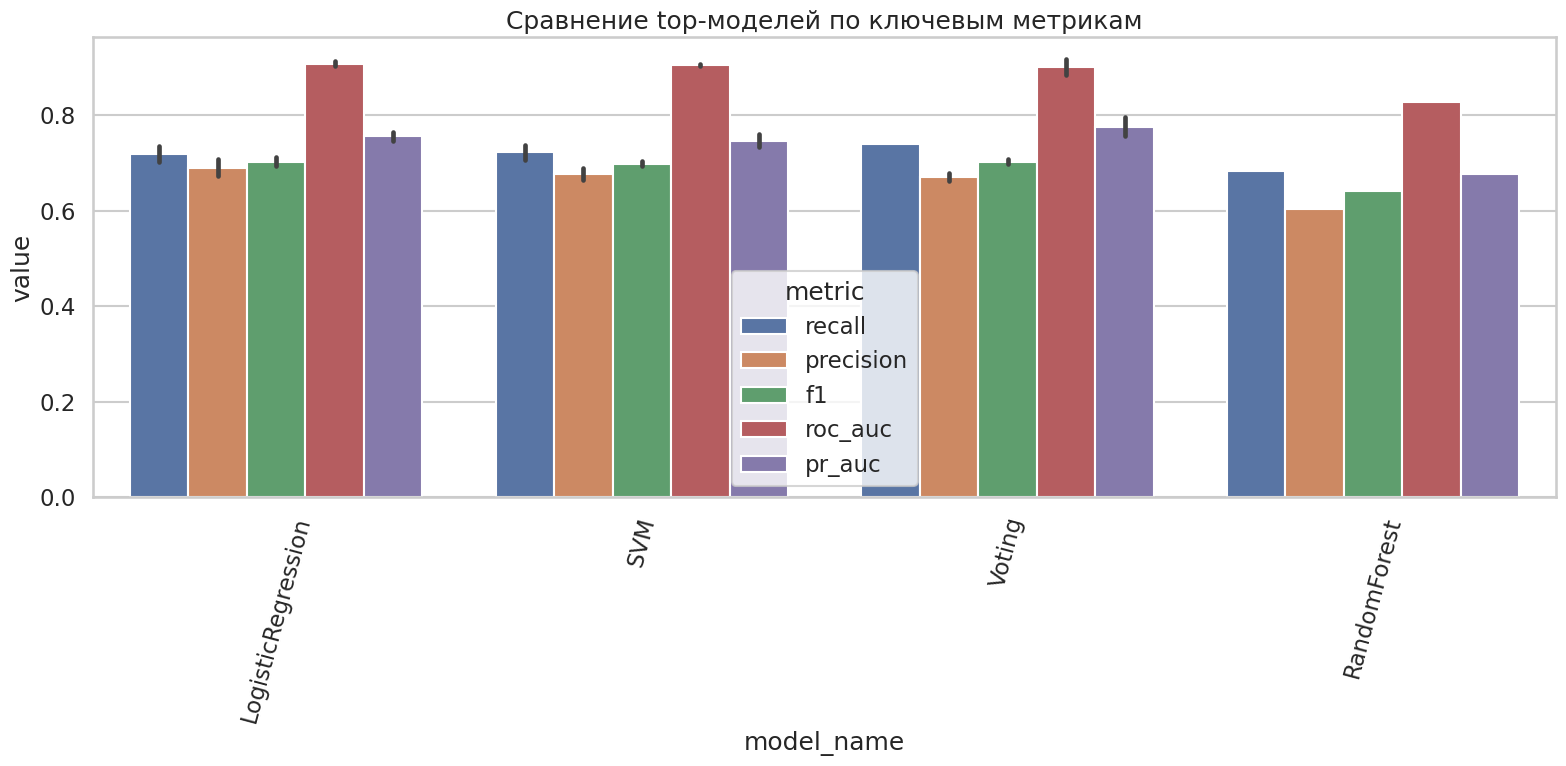

All summary tables have been saved to Google Drive.


In [25]:

if results_df.empty:
    raise RuntimeError("results_df пуст. Проверьте лог ошибок и доступность зависимостей.")

results_long = results_df.rename(columns={
    "Model": "model_name",
    "Method_Family": "method_family",
    "Variant": "variant",
    "Horizon": "horizon",
    "Window_Size": "window_size",
    "Tuned": "tuned",
    "Threshold": "threshold",
    "Precision_1": "precision",
    "Recall_1": "recall",
    "F1_1": "f1",
    "Accuracy": "accuracy",
    "ROC_AUC": "roc_auc",
    "AUC_PR": "pr_auc",
    "TN": "tn",
    "FP": "fp",
    "FN": "fn",
    "TP": "tp",
    "Train_Time": "train_time",
    "Notes": "notes",
    "Plot_Precision_Recall_Path": "plot_precision_recall_path",
    "Plot_ROC_AUC_Path": "plot_roc_auc_path",
    "Plot_Confusion_Matrix_Path": "plot_confusion_matrix_path",
    "Params_Path": "params_path",
})

common_cols = [
    "model_name", "method_family", "variant", "horizon", "window_size", "tuned", "threshold",
    "precision", "recall", "f1", "accuracy", "roc_auc", "pr_auc",
    "tn", "fp", "fn", "tp", "train_time", "notes",
    "plot_precision_recall_path", "plot_roc_auc_path", "plot_confusion_matrix_path", "params_path"
]

table_h2 = results_long[results_long["horizon"] == 2][common_cols].reset_index(drop=True)
table_h3 = results_long[results_long["horizon"] == 3][common_cols].reset_index(drop=True)

best_params_table = results_long[[
    "model_name", "method_family", "variant", "horizon", "window_size", "threshold", "precision", "recall", "f1", "notes"
]].copy()
best_params_table["best_params"] = results_df["Best_Params"].values
best_params_h2 = best_params_table[(best_params_table["horizon"] == 2) & (best_params_table["best_params"] != "{}")].reset_index(drop=True)
best_params_h3 = best_params_table[(best_params_table["horizon"] == 3) & (best_params_table["best_params"] != "{}")].reset_index(drop=True)

global_comparison = results_long[[
    "model_name", "method_family", "variant", "horizon", "window_size", "precision", "recall", "f1", "accuracy", "roc_auc", "pr_auc"
]].copy()
global_comparison = rank_results(global_comparison)
global_comparison["test_precision_floor_met"] = global_comparison["precision"] >= MIN_PRECISION

print("Table 1 — Detailed results for horizon 2")
display(table_h2)
print("Table 2 — Detailed results for horizon 3")
display(table_h3)
print("Table 3 — Best hyperparameters for tuned models, horizon 2")
display(best_params_h2)
print("Table 4 — Best hyperparameters for tuned models, horizon 3")
display(best_params_h3)
print("Table 5 — Global comparison table")
display(global_comparison)

best_overall_h2 = rank_results(global_comparison[global_comparison["horizon"] == 2]).head(1)
best_overall_h3 = rank_results(global_comparison[global_comparison["horizon"] == 3]).head(1)
print("Best model overall for horizon 2")
display(best_overall_h2)
print("Best model overall for horizon 3")
display(best_overall_h3)

best_per_family_rows = []
for family_name, subset in global_comparison.groupby("method_family"):
    best_per_family_rows.append(rank_results(subset).head(1))
best_per_family_df = pd.concat(best_per_family_rows, ignore_index=True) if best_per_family_rows else pd.DataFrame()
print("Best model per family")
display(best_per_family_df)

optimistic_test_selection_rows = []
for horizon_value in HORIZONS:
    horizon_df = global_comparison[global_comparison["horizon"] == horizon_value].copy()
    feasible_df = horizon_df[horizon_df["precision"] >= MIN_PRECISION].copy()
    if not feasible_df.empty:
        selected = feasible_df.sort_values(["recall", "pr_auc", "f1", "roc_auc"], ascending=[False, False, False, False]).head(1)
        selected = selected.assign(selection_note="Optimistic test-based selection: test precision floor was met.")
    else:
        selected = horizon_df.sort_values(["precision", "recall", "pr_auc"], ascending=[False, False, False]).head(1)
        selected = selected.assign(selection_note="No test row met MIN_PRECISION; fallback to highest test precision.")
    optimistic_test_selection_rows.append(selected)
optimistic_test_selection_df = pd.concat(optimistic_test_selection_rows, ignore_index=True) if optimistic_test_selection_rows else pd.DataFrame()
print("Optimistic best model selection using TEST precision floor and TEST recall")
print("Важно: это оптимистичная оценка, потому что test используется для выбора победителя среди экспериментов.")
display(optimistic_test_selection_df)

best_model_artifacts_df = model_artifacts_df.merge(
    global_comparison.head(20)[["model_name", "method_family", "variant", "horizon", "window_size", "rank_by_rule"]],
    on=["model_name", "method_family", "variant", "horizon", "window_size"],
    how="inner",
).sort_values("rank_by_rule").reset_index(drop=True)
print("Saved plot and parameter artifacts for top-ranked models")
display(best_model_artifacts_df)

for horizon in HORIZONS:
    for window_size in WINDOW_SIZES:
        title = f"Best models | horizon={horizon}, window={window_size}"
        subset = global_comparison[(global_comparison["horizon"] == horizon) & (global_comparison["window_size"] == window_size)]
        print(title)
        display(rank_results(subset).head(10))

top_plot_df = global_comparison.head(15).copy()
metric_plot_df = top_plot_df.melt(
    id_vars=["model_name", "method_family", "variant", "horizon", "window_size", "rank_by_rule"],
    value_vars=["recall", "precision", "f1", "roc_auc", "pr_auc"],
    var_name="metric",
    value_name="value",
)
plt.figure(figsize=(16, 8))
sns.barplot(data=metric_plot_df, x="model_name", y="value", hue="metric")
plt.xticks(rotation=75)
plt.title("Сравнение top-моделей по ключевым метрикам")
plt.tight_layout()
plt.show()

results_df.to_csv(os.path.join(RESULTS_DIR, 'results_summary.csv'), index=False)
table_h2.to_csv(os.path.join(RESULTS_DIR, "table_h2_detailed.csv"), index=False)
table_h3.to_csv(os.path.join(RESULTS_DIR, "table_h3_detailed.csv"), index=False)
best_params_h2.to_csv(os.path.join(RESULTS_DIR, "best_params_h2.csv"), index=False)
best_params_h3.to_csv(os.path.join(RESULTS_DIR, "best_params_h3.csv"), index=False)
global_comparison.to_csv(os.path.join(RESULTS_DIR, "global_comparison.csv"), index=False)
best_per_family_df.to_csv(os.path.join(RESULTS_DIR, "best_per_family.csv"), index=False)
best_model_artifacts_df.to_csv(os.path.join(RESULTS_DIR, "best_model_artifacts.csv"), index=False)
optimistic_test_selection_df.to_csv(os.path.join(RESULTS_DIR, "optimistic_test_selection.csv"), index=False)
persist_all_results()
print("All summary tables have been saved to Google Drive.")



## Раздел 17. Итоговое текстовое заключение

Ниже заключение генерируется автоматически по финальной таблице результатов.


In [26]:

def safe_first_value(df: pd.DataFrame, column: str, default: str = "н/д") -> str:
    if df is None or df.empty or column not in df.columns:
        return default
    value = df.iloc[0][column]
    return default if pd.isna(value) else str(value)

best_global_h2 = rank_results(global_comparison[global_comparison["horizon"] == 2]).head(1)
best_global_h3 = rank_results(global_comparison[global_comparison["horizon"] == 3]).head(1)
best_window_df = global_comparison.groupby("window_size")[["recall", "precision", "f1", "roc_auc", "pr_auc"]].mean().reset_index()
best_window_df = best_window_df.sort_values(["recall", "precision", "f1", "roc_auc"], ascending=False)
best_variant_df = global_comparison.groupby("variant")[["recall", "precision", "f1", "roc_auc", "pr_auc"]].mean().reset_index()
best_variant_df = best_variant_df.sort_values(["recall", "precision", "f1", "roc_auc"], ascending=False)
precision_floor_achieved = "да" if (global_comparison["precision"] >= MIN_PRECISION).any() else "нет"

family_ranking = (
    global_comparison.groupby("method_family")[["recall", "precision", "f1", "roc_auc", "pr_auc"]]
    .mean()
    .sort_values(["recall", "precision", "f1", "roc_auc"], ascending=False)
    .reset_index()
)

final_conclusion = f"""
### Автоматически сформированное заключение

- **Лучшее семейство моделей:** {safe_first_value(family_ranking, 'method_family')}.
- **Лучший конкретный модельный вариант для горизонта 2 дня:** {safe_first_value(best_global_h2, 'model_name')} | вариант `{safe_first_value(best_global_h2, 'variant')}` | окно `{safe_first_value(best_global_h2, 'window_size')}`.
- **Лучший конкретный модельный вариант для горизонта 3 дня:** {safe_first_value(best_global_h3, 'model_name')} | вариант `{safe_first_value(best_global_h3, 'variant')}` | окно `{safe_first_value(best_global_h3, 'window_size')}`.
- **Лучший размер окна в среднем по всем методам:** `{safe_first_value(best_window_df, 'window_size')}`.
- **Наиболее полезный вариант признаков в среднем:** `{safe_first_value(best_variant_df, 'variant')}`.
- **Порог `test precision >= {MIN_PRECISION:.2f}` был достигнут хотя бы одной моделью:** **{precision_floor_achieved}**.

### Практические рекомендации для дипломной работы

1. В тексте диплома стоит явно подчеркнуть, что разбиение выполнено **по годам**, а не по строкам, поскольку данные представляют собой независимые сезонные фрагменты.
2. Для основных выводов лучше опираться не только на accuracy, а прежде всего на **recall, precision и PR-AUC**, потому что задача имеет дисбаланс классов и прикладной приоритет по чувствительности.
3. Финальный выбор по `test_precision >= MIN_PRECISION` и `test_recall` является **оптимистичным**, потому что test используется для выбора победителя среди множества экспериментов; это надо явно указать в дипломе.
4. BLITECAST и SIMCAST в этом ноутбуке нужно описывать как **domain-aware approximations on daily aggregates**, а не как буквальное воспроизведение оригинальных DSS.
5. Для финальной версии диплома полезно вынести в приложение: таблицы гиперпараметров, годовые split-списки, списки отброшенных по корреляции признаков и итоговые confusion matrices для лучших моделей.
"""

display(Markdown(final_conclusion))



### Автоматически сформированное заключение

- **Лучшее семейство моделей:** ensemble.
- **Лучший конкретный модельный вариант для горизонта 2 дня:** LogisticRegression | вариант `tomek_only` | окно `7`.
- **Лучший конкретный модельный вариант для горизонта 3 дня:** н/д | вариант `н/д` | окно `н/д`.
- **Лучший размер окна в среднем по всем методам:** `7.0`.
- **Наиболее полезный вариант признаков в среднем:** `temporal_fe`.
- **Порог `test precision >= 0.60` был достигнут хотя бы одной моделью:** **да**.

### Практические рекомендации для дипломной работы

1. В тексте диплома стоит явно подчеркнуть, что разбиение выполнено **по годам**, а не по строкам, поскольку данные представляют собой независимые сезонные фрагменты.
2. Для основных выводов лучше опираться не только на accuracy, а прежде всего на **recall, precision и PR-AUC**, потому что задача имеет дисбаланс классов и прикладной приоритет по чувствительности.
3. Финальный выбор по `test_precision >= MIN_PRECISION` и `test_recall` является **оптимистичным**, потому что test используется для выбора победителя среди множества экспериментов; это надо явно указать в дипломе.
4. BLITECAST и SIMCAST в этом ноутбуке нужно описывать как **domain-aware approximations on daily aggregates**, а не как буквальное воспроизведение оригинальных DSS.
5. Для финальной версии диплома полезно вынести в приложение: таблицы гиперпараметров, годовые split-списки, списки отброшенных по корреляции признаков и итоговые confusion matrices для лучших моделей.


In [27]:
import shutil

shutil.make_archive('/kaggle/working/diploma_results', 'zip', '/kaggle/working/diploma_results')

'/kaggle/working/diploma_results.zip'

Table 1 — Detailed results for horizon 2


,model_name,method_family,variant,horizon,window_size,tuned,threshold,precision,recall,f1,accuracy,roc_auc,pr_auc,tn,fp,fn,tp,train_time,notes,plot_precision_recall_path,plot_roc_auc_path,plot_confusion_matrix_path,params_path
0,GRU,dl,baseline_sequence,2,7,True,0.667890,NaN,NaN,NaN,0.831197,0.874408,0.734781,310,32,47,79,75.350683,PyTorch GRU with year-aware sequences; multi_g...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...
1,GRU,dl,baseline_sequence,2,12,True,0.776292,NaN,NaN,NaN,0.783105,0.813015,0.587238,307,20,75,36,91.674242,PyTorch GRU with year-aware sequences; multi_g...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...
2,TFT,dl,baseline_sequence,2,7,True,0.588719,0.714286,0.162602,0.264901,0.759740,0.789577,0.593946,331,8,103,20,639.104024,TemporalFusionTransformer with categorical tar...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...
3,TFT,dl,baseline_sequence,2,12,True,0.440003,0.655738,0.366972,0.470588,0.791667,0.777800,0.564116,302,21,69,40,625.476668,TemporalFusionTransformer with categorical tar...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...
4,LogisticRegression,ml,baseline,2,7,True,0.364872,0.671141,0.724638,0.696864,0.827381,0.904589,0.765353,317,49,38,100,16.690716,Benchmark-style compact tabular features: day ...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...
5,LogisticRegression,ml,interaction_fe,2,7,True,0.372487,0.705882,0.695652,0.700730,0.837302,0.901798,0.761210,326,40,42,96,16.828692,Benchmark-style compact tabular features: day ...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...
6,LogisticRegression,ml,temporal_fe,2,7,True,0.706597,0.741379,0.699187,0.719665,0.854978,0.921721,0.770876,309,30,37,86,17.890109,Benchmark-style compact tabular features: day ...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...
7,LogisticRegression,ml,tomek_only,2,7,True,0.597783,0.668790,0.760870,0.711864,0.831349,0.898848,0.755643,314,52,33,105,16.576913,Benchmark-style compact tabular features: day ...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...
8,LogisticRegression,ml,tomek_interaction_fe,2,7,True,0.629914,0.668966,0.702899,0.685512,0.823413,0.903857,0.764287,318,48,41,97,16.785618,Benchmark-style compact tabular features: day ...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...
9,LogisticRegression,ml,tomek_temporal_fe,2,7,True,0.552516,0.691729,0.747967,0.718750,0.844156,0.905365,0.731267,298,41,31,92,17.753284,Benchmark-style compact tabular features: day ...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_plots/20...,/kaggle/working/diploma_results/model_artifact...


Table 2 — Detailed results for horizon 3


,model_name,method_family,variant,horizon,window_size,tuned,threshold,precision,recall,f1,accuracy,roc_auc,pr_auc,tn,fp,fn,tp,train_time,notes,plot_precision_recall_path,plot_roc_auc_path,plot_confusion_matrix_path,params_path


Table 3 — Best hyperparameters for tuned models, horizon 2


...

,model_name,method_family,variant,horizon,window_size,precision,recall,f1,accuracy,roc_auc,pr_auc,precision_floor_met,rank_by_rule,test_precision_floor_met


Best models | horizon=2, window=7


,model_name,method_family,variant,horizon,window_size,precision,recall,f1,accuracy,roc_auc,pr_auc,precision_floor_met,rank_by_rule,test_precision_floor_met
0,LogisticRegression,ml,tomek_interaction_temporal_fe,2,7,0.661972,0.764228,0.709434,0.833333,0.912728,0.728891,True,1,True
1,LogisticRegression,ml,tomek_only,2,7,0.668790,0.760870,0.711864,0.831349,0.898848,0.755643,True,2,True
2,LogisticRegression,ml,temporal_fe,2,7,0.671533,0.747967,0.707692,0.835498,0.921721,0.757671,True,3,True
3,LogisticRegression,ml,tomek_temporal_fe,2,7,0.691729,0.747967,0.718750,0.844156,0.905365,0.731267,True,4,True
4,SVM,ml,tomek_interaction_fe,2,7,0.656051,0.746377,0.698305,0.823413,0.904253,0.760102,True,5,True
5,Voting,ensemble,temporal_fe,2,7,0.679104,0.739837,0.708171,0.837662,0.917548,0.796031,True,6,True
6,LogisticRegression,ml,tomek_temporal_fe,2,7,0.684211,0.739837,0.710938,0.839827,0.921337,0.761065,True,7,True
7,Voting,ensemble,baseline,2,7,0.662338,0.739130,0.698630,0.825397,0.884058,0.755878,True,8,True
8,LogisticRegression,ml,baseline,2,7,0.671141,0.724638,0.696864,0.827381,0.904589,0.765353,True,9,True
9,SVM,ml,baseline,2,7,0.666667,0.724638,0.694444,0.825397,0.900907,0.750654,True,10,True


Best models | horizon=2, window=9


,model_name,method_family,variant,horizon,window_size,precision,recall,f1,accuracy,roc_auc,pr_auc,precision_floor_met,rank_by_rule,test_precision_floor_met


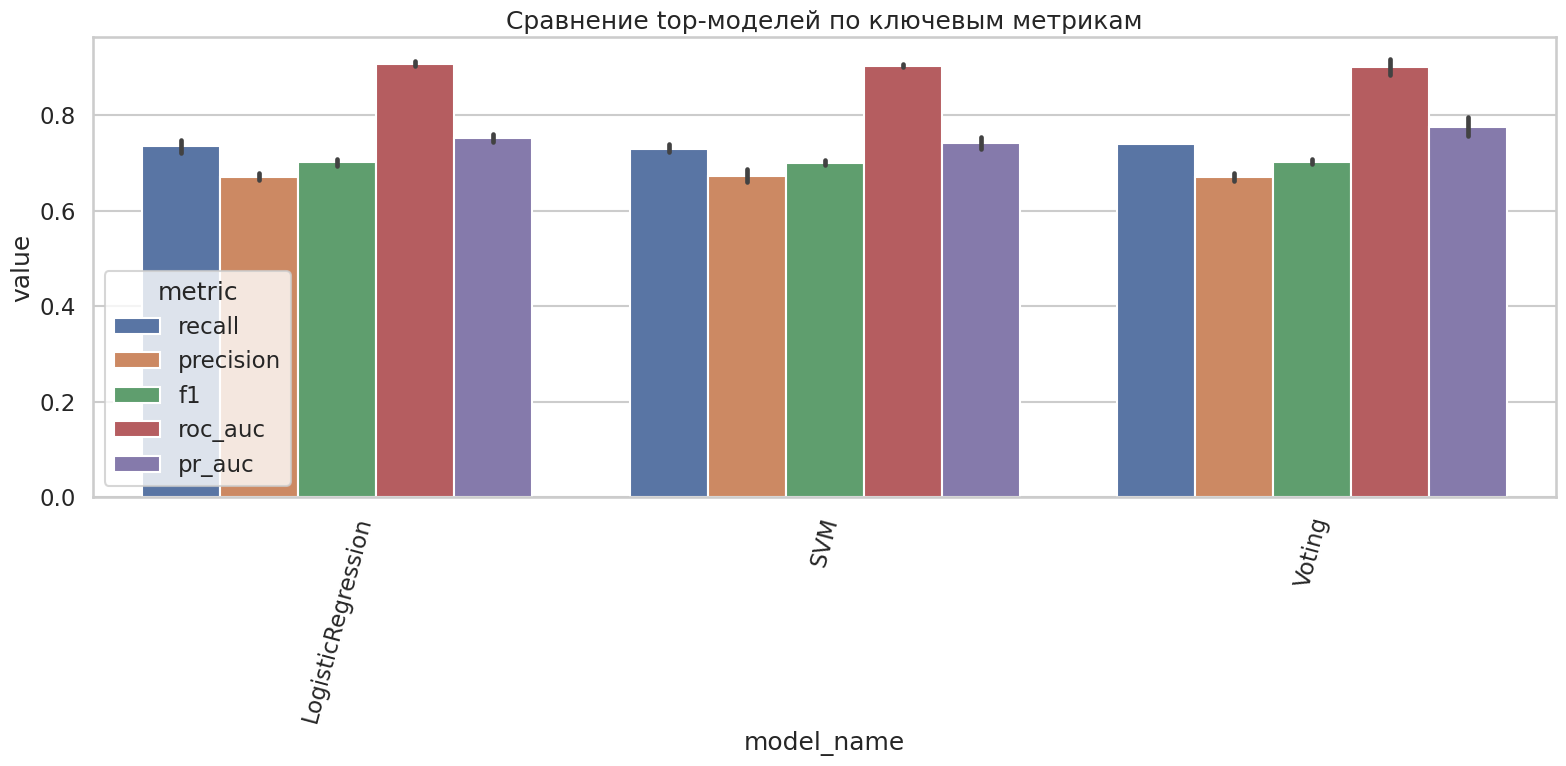

All summary tables have been saved to Google Drive.


In [41]:

if results_df.empty:
    raise RuntimeError("results_df пуст. Проверьте лог ошибок и доступность зависимостей.")

results_long = results_df.rename(columns={
    "Model": "model_name",
    "Method_Family": "method_family",
    "Variant": "variant",
    "Horizon": "horizon",
    "Window_Size": "window_size",
    "Tuned": "tuned",
    "Threshold": "threshold",
    "Precision_1": "precision",
    "Recall_1": "recall",
    "F1_1": "f1",
    "Accuracy": "accuracy",
    "ROC_AUC": "roc_auc",
    "AUC_PR": "pr_auc",
    "TN": "tn",
    "FP": "fp",
    "FN": "fn",
    "TP": "tp",
    "Train_Time": "train_time",
    "Notes": "notes",
    "Plot_Precision_Recall_Path": "plot_precision_recall_path",
    "Plot_ROC_AUC_Path": "plot_roc_auc_path",
    "Plot_Confusion_Matrix_Path": "plot_confusion_matrix_path",
    "Params_Path": "params_path",
})

common_cols = [
    "model_name", "method_family", "variant", "horizon", "window_size", "tuned", "threshold",
    "precision", "recall", "f1", "accuracy", "roc_auc", "pr_auc",
    "tn", "fp", "fn", "tp", "train_time", "notes",
    "plot_precision_recall_path", "plot_roc_auc_path", "plot_confusion_matrix_path", "params_path"
]

table_h2 = results_long[results_long["horizon"] == 2][common_cols].reset_index(drop=True)
table_h3 = results_long[results_long["horizon"] == 3][common_cols].reset_index(drop=True)

best_params_table = results_long[[
    "model_name", "method_family", "variant", "horizon", "window_size", "threshold", "precision", "recall", "f1", "notes"
]].copy()
best_params_table["best_params"] = results_df["Best_Params"].values
best_params_h2 = best_params_table[(best_params_table["horizon"] == 2) & (best_params_table["best_params"] != "{}")].reset_index(drop=True)
best_params_h3 = best_params_table[(best_params_table["horizon"] == 3) & (best_params_table["best_params"] != "{}")].reset_index(drop=True)

global_comparison = results_long[[
    "model_name", "method_family", "variant", "horizon", "window_size", "precision", "recall", "f1", "accuracy", "roc_auc", "pr_auc"
]].copy()
global_comparison = rank_results(global_comparison)
global_comparison["test_precision_floor_met"] = global_comparison["precision"] >= MIN_PRECISION

print("Table 1 — Detailed results for horizon 2")
display(table_h2)
print("Table 2 — Detailed results for horizon 3")
display(table_h3)
print("Table 3 — Best hyperparameters for tuned models, horizon 2")
display(best_params_h2)
print("Table 4 — Best hyperparameters for tuned models, horizon 3")
display(best_params_h3)
print("Table 5 — Global comparison table")
display(global_comparison)

best_overall_h2 = rank_results(global_comparison[global_comparison["horizon"] == 2]).head(1)
best_overall_h3 = rank_results(global_comparison[global_comparison["horizon"] == 3]).head(1)
print("Best model overall for horizon 2")
display(best_overall_h2)
print("Best model overall for horizon 3")
display(best_overall_h3)

best_per_family_rows = []
for family_name, subset in global_comparison.groupby("method_family"):
    best_per_family_rows.append(rank_results(subset).head(1))
best_per_family_df = pd.concat(best_per_family_rows, ignore_index=True) if best_per_family_rows else pd.DataFrame()
print("Best model per family")
display(best_per_family_df)

optimistic_test_selection_rows = []
for horizon_value in HORIZONS:
    horizon_df = global_comparison[global_comparison["horizon"] == horizon_value].copy()
    feasible_df = horizon_df[horizon_df["precision"] >= MIN_PRECISION].copy()
    if not feasible_df.empty:
        selected = feasible_df.sort_values(["recall", "pr_auc", "f1", "roc_auc"], ascending=[False, False, False, False]).head(1)
        selected = selected.assign(selection_note="Optimistic test-based selection: test precision floor was met.")
    else:
        selected = horizon_df.sort_values(["precision", "recall", "pr_auc"], ascending=[False, False, False]).head(1)
        selected = selected.assign(selection_note="No test row met MIN_PRECISION; fallback to highest test precision.")
    optimistic_test_selection_rows.append(selected)
optimistic_test_selection_df = pd.concat(optimistic_test_selection_rows, ignore_index=True) if optimistic_test_selection_rows else pd.DataFrame()
print("Optimistic best model selection using TEST precision floor and TEST recall")
print("Важно: это оптимистичная оценка, потому что test используется для выбора победителя среди экспериментов.")
display(optimistic_test_selection_df)

best_model_artifacts_df = model_artifacts_df.merge(
    global_comparison.head(20)[["model_name", "method_family", "variant", "horizon", "window_size", "rank_by_rule"]],
    on=["model_name", "method_family", "variant", "horizon", "window_size"],
    how="inner",
).sort_values("rank_by_rule").reset_index(drop=True)
print("Saved plot and parameter artifacts for top-ranked models")
display(best_model_artifacts_df)

for horizon in HORIZONS:
    for window_size in WINDOW_SIZES:
        title = f"Best models | horizon={horizon}, window={window_size}"
        subset = global_comparison[(global_comparison["horizon"] == horizon) & (global_comparison["window_size"] == window_size)]
        print(title)
        display(rank_results(subset).head(10))

top_plot_df = global_comparison.head(15).copy()
metric_plot_df = top_plot_df.melt(
    id_vars=["model_name", "method_family", "variant", "horizon", "window_size", "rank_by_rule"],
    value_vars=["recall", "precision", "f1", "roc_auc", "pr_auc"],
    var_name="metric",
    value_name="value",
)
plt.figure(figsize=(16, 8))
sns.barplot(data=metric_plot_df, x="model_name", y="value", hue="metric")
plt.xticks(rotation=75)
plt.title("Сравнение top-моделей по ключевым метрикам")
plt.tight_layout()
plt.show()

results_df.to_csv(os.path.join(RESULTS_DIR, 'results_summary.csv'), index=False)
table_h2.to_csv(os.path.join(RESULTS_DIR, "table_h2_detailed.csv"), index=False)
table_h3.to_csv(os.path.join(RESULTS_DIR, "table_h3_detailed.csv"), index=False)
best_params_h2.to_csv(os.path.join(RESULTS_DIR, "best_params_h2.csv"), index=False)
best_params_h3.to_csv(os.path.join(RESULTS_DIR, "best_params_h3.csv"), index=False)
global_comparison.to_csv(os.path.join(RESULTS_DIR, "global_comparison.csv"), index=False)
best_per_family_df.to_csv(os.path.join(RESULTS_DIR, "best_per_family.csv"), index=False)
best_model_artifacts_df.to_csv(os.path.join(RESULTS_DIR, "best_model_artifacts.csv"), index=False)
optimistic_test_selection_df.to_csv(os.path.join(RESULTS_DIR, "optimistic_test_selection.csv"), index=False)
persist_all_results()
print("All summary tables have been saved to Google Drive.")


In [43]:

logreg_candidates = global_comparison[
    global_comparison["model_name"].astype(str).str.lower().str.replace(" ", "", regex=False).isin(
        ["logisticregression"]
    )
].copy()

logreg_feasible = logreg_candidates[
    (logreg_candidates["recall"] > 0.80) &
    (logreg_candidates["precision"] > 0.5)
].copy()

if logreg_feasible.empty:
    print("Нет Logistic Regression экспериментов, одновременно удовлетворяющих recall > 0.8 и precision > 0.6.")
    print("Ниже показаны лучшие Logistic Regression по ближайшему компромиссу.")
    logreg_selection_df = logreg_candidates.assign(
        constraint_met=False,
        joint_score=lambda df: 0.9 * df["recall"].fillna(0) + 0.1 * df["precision"].fillna(0),
    ).sort_values(
        ["joint_score", "recall", "precision", "f1", "pr_auc", "roc_auc"],
        ascending=[False, False, False, False, False, False],
    ).reset_index(drop=True)
else:
    logreg_selection_df = logreg_feasible.assign(
        constraint_met=True,
        joint_score=lambda df: 0.5 * df["recall"].fillna(0) + 0.5 * df["precision"].fillna(0),
    ).sort_values(
        ["joint_score", "recall", "precision", "f1", "pr_auc", "roc_auc"],
        ascending=[False, False, False, False, False, False],
    ).reset_index(drop=True)

best_logreg_constrained = logreg_selection_df.head(1).copy()

print("Лучшие Logistic Regression при ограничениях recall > 0.8 и precision > 0.6")
display(logreg_selection_df)

print("Лучший Logistic Regression по совместной оптимизации recall и precision")
display(best_logreg_constrained)

logreg_selection_path = os.path.join(RESULTS_DIR, "best_logistic_regression_recall_gt_08_precision_gt_06.csv")
logreg_selection_df.to_csv(logreg_selection_path, index=False)
print(f"Таблица сохранена: {logreg_selection_path}")


Нет Logistic Regression экспериментов, одновременно удовлетворяющих recall > 0.8 и precision > 0.6.
Ниже показаны лучшие Logistic Regression по ближайшему компромиссу.
Лучшие Logistic Regression при ограничениях recall > 0.8 и precision > 0.6


,model_name,method_family,variant,horizon,window_size,precision,recall,f1,accuracy,roc_auc,pr_auc,precision_floor_met,rank_by_rule,test_precision_floor_met,constraint_met,joint_score
0,LogisticRegression,ml,tomek_interaction_temporal_fe,2,7,0.661972,0.764228,0.709434,0.833333,0.912728,0.728891,True,1,True,False,0.754002
1,LogisticRegression,ml,tomek_only,2,7,0.668790,0.760870,0.711864,0.831349,0.898848,0.755643,True,2,True,False,0.751662
2,LogisticRegression,ml,tomek_temporal_fe,2,7,0.691729,0.747967,0.718750,0.844156,0.905365,0.731267,True,4,True,False,0.742344
3,LogisticRegression,ml,temporal_fe,2,7,0.671533,0.747967,0.707692,0.835498,0.921721,0.757671,True,3,True,False,0.740324
4,LogisticRegression,ml,tomek_temporal_fe,2,7,0.684211,0.739837,0.710938,0.839827,0.921337,0.761065,True,7,True,False,0.734275
5,LogisticRegression,ml,baseline,2,7,0.671141,0.724638,0.696864,0.827381,0.904589,0.765353,True,9,True,False,0.719288
6,LogisticRegression,ml,interaction_fe,2,7,0.655629,0.717391,0.685121,0.819444,0.904827,0.758142,True,13,True,False,0.711215
7,LogisticRegression,ml,tomek_only,2,7,0.671233,0.710145,0.690141,0.825397,0.902352,0.758663,True,14,True,False,0.706254
8,LogisticRegression,ml,temporal_fe,2,7,0.741379,0.699187,0.719665,0.854978,0.921721,0.770876,True,17,True,False,0.703406
9,LogisticRegression,ml,tomek_interaction_fe,2,7,0.668966,0.702899,0.685512,0.823413,0.903857,0.764287,True,15,True,False,0.699505


Лучший Logistic Regression по совместной оптимизации recall и precision


,model_name,method_family,variant,horizon,window_size,precision,recall,f1,accuracy,roc_auc,pr_auc,precision_floor_met,rank_by_rule,test_precision_floor_met,constraint_met,joint_score
0,LogisticRegression,ml,tomek_interaction_temporal_fe,2,7,0.661972,0.764228,0.709434,0.833333,0.912728,0.728891,True,1,True,False,0.754002


Таблица сохранена: /kaggle/working/diploma_results/best_logistic_regression_recall_gt_08_precision_gt_06.csv


In [45]:
from sklearn.metrics import precision_recall_curve
import pandas as pd
import numpy as np

selected_runs = []

for run_id, run_data in logreg_runs.items():
    y_val = run_data["y_val"]
    y_val_proba = run_data["y_val_proba"]

    precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)

    pr_table = pd.DataFrame({
        "threshold": thresholds,
        "precision": precision[:-1],
        "recall": recall[:-1],
    })

    feasible = pr_table[
        (pr_table["recall"] >= 0.8) &
        (pr_table["precision"] >= 0.6)
    ].copy()

    if feasible.empty:
        continue

    best_point = feasible.sort_values(
        ["recall", "precision", "threshold"],
        ascending=[False, False, True]
    ).iloc[0]

    selected_runs.append({
        "run_id": run_id,
        "best_threshold": best_point["threshold"],
        "recall": best_point["recall"],
        "precision": best_point["precision"],
    })

selected_runs_df = pd.DataFrame(selected_runs).sort_values(
    ["recall", "precision"],
    ascending=False
).reset_index(drop=True)

display(selected_runs_df)

NameError: name 'logreg_runs' is not defined

In [48]:
tuning_result = optuna_tune_tabular_model(model_key, X_train, y_train, X_val, y_val, n_trials=tune_trials)
best_params = tuning_result["best_params"]

model = build_model_by_name(model_key, best_params, y_train)
model = fit_estimator(model_key, model, X_train, y_train, X_val, y_val)

val_scores = get_score_vector(model, X_val)
test_scores = get_score_vector(model, X_test)

threshold_info = search_threshold_with_min_recall(
    y_val,
    val_scores,
    min_recall=0.8,
    min_precision=0.6,
)

if not threshold_info["found"]:
    raise ValueError("No validation threshold satisfies recall >= 0.8 and precision >= 0.6")

best_threshold = threshold_info["threshold"]

val_pred = (val_scores >= best_threshold).astype(int)
test_pred = (test_scores >= best_threshold).astype(int)

[I 2026-04-21 19:56:20,204] A new study created in memory with name: no-name-28665083-4cc0-4a96-a822-345ae6ca7ab3
[I 2026-04-21 19:56:24,991] Trial 0 finished with value: 1.6824181818181816 and parameters: {'iterations': 250, 'depth': 5, 'learning_rate': 0.06142200213023761, 'l2_leaf_reg': 4.477845158119077, 'random_strength': 2.148972637681668}. Best is trial 0 with value: 1.6824181818181816.
[I 2026-04-21 19:56:30,923] Trial 1 finished with value: 1.6642396694214876 and parameters: {'iterations': 400, 'depth': 5, 'learning_rate': 0.025704305721319872, 'l2_leaf_reg': 5.514656323063928, 'random_strength': 2.7840853822485996}. Best is trial 0 with value: 1.6824181818181816.
[I 2026-04-21 19:57:51,763] Trial 2 finished with value: 1.4642435064935064 and parameters: {'iterations': 550, 'depth': 10, 'learning_rate': 0.295210275801231, 'l2_leaf_reg': 9.992611724974703, 'random_strength': 2.239691711173641}. Best is trial 0 with value: 1.6824181818181816.
[I 2026-04-21 19:58:15,120] Trial 3 

ValueError: No validation threshold satisfies recall >= 0.8 and precision >= 0.6